## Import

In [1]:
import numpy as np
import scipy
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import to_hex

import warnings
import re
import matplotlib.image as mpimg
import os
import shutil
import csv
import glob

from PIL import Image
from itertools import product

from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit

from functools import partial

# Полностью отключить все предупреждения
warnings.filterwarnings("ignore")

os.makedirs("ims", exist_ok=True)
# os.makedirs("ims/current", exist_ok=True)
os.makedirs("ims/all", exist_ok=True)

# VERY CAREFULLY not to delete other folders!
if os.path.isdir("all_data"):
    shutil.rmtree("all_data")
    print("The all_data folder is deleted and created again")
    print(" ")

os.makedirs("all_data", exist_ok=True)

os.makedirs("all_data/inputs", exist_ok=True)

os.makedirs("all_data/current_energy", exist_ok=True)
os.makedirs("all_data/current_energy/data", exist_ok=True)
os.makedirs("all_data/current_energy/ims", exist_ok=True)
os.makedirs("all_data/current_energy/ims/all", exist_ok=True)
os.makedirs("all_data/current_energy/ims/energy_current", exist_ok=True)

os.makedirs("all_data/current_energy/ims/all/png", exist_ok=True)
os.makedirs("all_data/current_energy/ims/all/pdf", exist_ok=True)

os.makedirs("all_data/current_energy/ims/energy_current/png", exist_ok=True)
os.makedirs("all_data/current_energy/ims/energy_current/pdf", exist_ok=True)



os.makedirs("all_data/hhg", exist_ok=True)
os.makedirs("all_data/hhg/data", exist_ok=True)
os.makedirs("all_data/hhg/ims", exist_ok=True)
os.makedirs("all_data/hhg/ims/png", exist_ok=True)
os.makedirs("all_data/hhg/ims/pdf", exist_ok=True)

os.makedirs("all_data/nonlinear", exist_ok=True)

os.makedirs("all_data/drude", exist_ok=True)
os.makedirs("all_data/drude/data", exist_ok=True)
os.makedirs("all_data/drude/data/current", exist_ok=True)
os.makedirs("all_data/drude/data/m", exist_ok=True)
os.makedirs("all_data/drude/data/abc", exist_ok=True)
os.makedirs("all_data/drude/data/tau", exist_ok=True)
os.makedirs("all_data/drude/data/n_ex", exist_ok=True)
os.makedirs("all_data/drude/ims", exist_ok=True)

os.makedirs("all_data/drude/ims/png", exist_ok=True)
os.makedirs("all_data/drude/ims/pdf", exist_ok=True)

os.makedirs("all_data/fid", exist_ok=True)
os.makedirs("all_data/fid/z", exist_ok=True)
os.makedirs("all_data/fid/z/data", exist_ok=True)
os.makedirs("all_data/fid/z/ims", exist_ok=True)
os.makedirs("all_data/fid/z/ims/png", exist_ok=True)
os.makedirs("all_data/fid/z/ims/pdf", exist_ok=True)


volume = 160.1 # для Si в A^3

# m0_cut_1 = 10500  # 21 fs: for exp fit
# m0_cut_2 = 6250   # 12.5 fs: for full drude fit (needs to be adjusted in accordance to z_pump energy)
# # 3749 (7.5 fms), 5999 (12 fms)

# m0_cut_3 = 5250 # 10.5 fs: start of integration for Δk analysis. half of probe pulse duration

# In[116]:


plt.rcParams['font.family'] = 'serif'
import matplotlib
# matplotlib.use('Agg')
# print(matplotlib.get_backend())


The all_data folder is deleted and created again
 


## all plots func

In [2]:
def plot_nonlinear_response_v4(folder, ax, j):


    t_probe, t_pump = get_pulse_durations(folder)

    m0_cut_1 = int(500*t_probe) # duration of probe pulse for exp fit after it
    m0_cut_3 = int(m0_cut_1/2)  # start of integration for Δk analysis. half of probe pulse duration

    m0_cut_2 = m0_cut_3+500 # adjustable. start for drude x-fit (needs to be adjusted in accordance to z_pump energy)

    m0_cut_4 = int(500*(t_probe+t_pump)/2) # pump exp fit, at the end of the pump pulse

    # Загрузка данных, пропуская строки с комментариями (начинаются с #)
    data_both = pd.read_csv(
        folder + '/both_pulses_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )

    data_pump = pd.read_csv(
        folder + '/pump_pulse_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )

    data_probe = pd.read_csv(
        folder + '/probe_pulse_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )


    # Назначим читаемые имена колонкам
    data_both.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']

    data_pump.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']

    data_probe.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']


    t = data_both['time_fs']


    Jm_both_z  =  data_both['Jm_z']
    Jm_pump_z  =  data_pump['Jm_z']

    Jm_both_x  =  data_both['Jm_x']
    Jm_pump_x  =  data_pump['Jm_x']
    Jm_probe_x =  data_probe['Jm_x']

    Jm_both_y  =  data_both['Jm_y']
    Jm_pump_y  =  data_pump['Jm_y']
    Jm_probe_y =  data_probe['Jm_y']


    El_f_pump_z = data_both['E_ext_z']
    El_f_probe_x = data_both['E_ext_x']


    # 1:Time[fs] 2:Ac_ext_x[fs*V/Angstrom] 3:Ac_ext_y[fs*V/Angstrom] 4:Ac_ext_z[fs*V/Angstrom]
    #5:E_ext_x[V/Angstrom] 6:E_ext_y[V/Angstrom] 7:E_ext_z[V/Angstrom] 8:Ac_tot_x[fs*V/Angstrom]
    # 9:Ac_tot_y[fs*V/Angstrom] 10:Ac_tot_z[fs*V/Angstrom] 11:E_tot_x[V/Angstrom]
    # 12:E_tot_y[V/Angstrom] 13:E_tot_z[V/Angstrom]  14:Jm_x[1/fs*Angstrom^2] 15:Jm_y[1/fs*Angstrom^2] 16:Jm_z[1/fs*Angstrom^2]


    # Построим графики
    plt.figure(figsize=(10, 12.5))

    # Общий заголовок для всей фигуры
    plt.suptitle(' '.join(re.split('[/_]', folder)), fontsize=14, y=0.99)

    # Первый график: внешнее поле по z
    plt.subplot(5, 2, 1)
    plt.plot(t, El_f_pump_z, label='E_ext_z', color='#2CD311')
    plt.xlabel('Time [fs]')
    plt.ylabel('E [V/Å]')
    plt.title('Pump external electric field z')
    plt.grid(True)
    #plt.legend()
    plt.tight_layout()

    # Второй график: внешнее поле по x
    plt.subplot(5, 2, 2)
    plt.plot(t, El_f_probe_x, label='E_ext_z', color='c')
    plt.xlabel('Time [fs]')
    plt.ylabel('E [V/Å]')
    plt.title('Probe external electric field x')
    plt.grid(True)
    #plt.legend()
    plt.tight_layout()

    # # Четвертый график: суммарный ток по z
    # plt.subplot(5, 2, 4)
    # plt.plot(t, Jm_pump_z, color='magenta')
    # plt.xlabel('Time [fs]')
    # plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
    # plt.title('Matter current density along z, only pump')
    # plt.grid(True)

    # plt.tight_layout()





    
    t_array_cut = np.array(t[m0_cut_4:])[::50]
    j_exp = np.array(Jm_pump_z[m0_cut_4:])[::50]
    # (dummy_t, j0, j_final, tau)
    p0 = [0.02, 0, 6.65]   # начальные приближения (n, tau)
    popt, pcov = curve_fit(drude_exp_fit_v2_pump, t_array_cut, j_exp, p0=p0)
    j0, j_final, tau_pump= popt
    j_fit = drude_exp_fit_v2_pump(0, j0, j_final, tau_pump)

    # ratio = j_final/max(delta_Jm_x)

    # Разностный ток по x
    plt.subplot(5, 2, 4)
    plt.plot(t, Jm_pump_z, color='m')
    if tau_pump<30:
        plt.plot(t_array_cut, j_fit, '--', label=rf"$\tau = {tau_pump:.2f}\ \mathrm{{fs}}$", color='r')
    else: plt.plot(t_array_cut, j_fit, '--', color='r')
    plt.xlabel('Time [fs]')
    plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
    plt.title('Matter current density along z, only pump')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()



    
    



    product_both_z = El_f_pump_z * Jm_both_z * volume
    # Разность по времени
    dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
    integral_both_z = np.cumsum(product_both_z * dt)

    product_both_x = El_f_probe_x * Jm_both_x * volume
    # Разность по времени
    dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
    integral_both_x = np.cumsum(product_both_x * dt)

    product_delta_x = El_f_probe_x * (Jm_both_x - Jm_pump_x - Jm_probe_x) * volume
    # Разность по времени
    dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
    integral_delta_x = np.cumsum(product_delta_x * dt)



    # Построение графика изменения энергии во времени
    plt.subplot(5, 2, 3)
    # plt.plot(energy_data['Time_fs'], energy_data['Delta_E_eV'], label='ΔE = E_total - E_initial', color='r')
    plt.plot(t, -integral_both_z, label='ΔE = E_total - E_initial', color='r')
    plt.xlabel('Time [fs]')
    plt.ylabel('E [eV]')
    plt.title('Energy transfer per unit cell along z')
    plt.grid(True)
    #plt.legend()
    plt.tight_layout()



    # Построение графика изменения энергии во времени
    plt.subplot(5, 2, 5)
    # plt.plot(energy_data['Time_fs'], energy_data['Delta_E_eV'], label='ΔE = E_total - E_initial', color='r')
    plt.plot(t, -integral_both_x, label='ΔE = E_total - E_initial', color='blue')
    plt.xlabel('Time [fs]')
    plt.ylabel('E [eV]')
    plt.title('Energy transfer per unit cell along x')
    plt.grid(True)
    #plt.legend()
    plt.tight_layout()


    # Построение графика изменения энергии во времени
    plt.subplot(5, 2, 6)
    # plt.plot(energy_data['Time_fs'], energy_data['Delta_E_eV'], label='ΔE = E_total - E_initial', color='r')
    plt.plot(t, -integral_delta_x, label='ΔE = E_total - E_initial', color='black')
    plt.xlabel('Time [fs]')
    plt.ylabel('E [eV]')
    plt.title('Δ energy transfer per unit cell along x')
    plt.grid(True)
    #plt.legend()
    plt.tight_layout()



    # Суммарный ток по x
    plt.subplot(5, 2, 7)
    plt.plot(t, Jm_both_x, color='#DC143C')
    plt.xlabel('Time [fs]')
    plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
    plt.title('Full matter current density along x')
    plt.grid(True)
    plt.tight_layout()
    
    
    
    
    delta_Jm_x = Jm_both_x - Jm_pump_x - Jm_probe_x

    
    t_array_cut = np.array(t[m0_cut_1:])[::50]
    j_exp = np.array(delta_Jm_x[m0_cut_1:])[::50]
    # (dummy_t, j0, j_final, tau)
    p0 = [0.03, 0.01, 6.65]   # начальные приближения (n, tau)
    popt, pcov = curve_fit(drude_current_v1, t_array_cut, j_exp, p0=p0)
    j0, j_final, tau= popt
    j_fit = drude_current_v1(0, j0, j_final, tau)

    ratio = j_final/max(delta_Jm_x)

    # Разностный ток по x
    plt.subplot(5, 2, 8)
    plt.plot(t, (Jm_both_x - Jm_pump_x - Jm_probe_x), color='#00FF7F')
    plt.plot(t_array_cut, j_fit, '--', label=rf"$\tau = {tau:.2f}\ \mathrm{{fs}} \quad j_{{\rm final}} : j_{{\rm max}} = {ratio:.2f}$", color='r')
    plt.xlabel('Time [fs]')
    plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
    plt.title('Δ matter current density along x')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()




    # Суммарный ток по y
    plt.subplot(5, 2, 9)
    plt.plot(t, Jm_both_y, color='#00BFFF')
    plt.xlabel('Time [fs]')
    plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
    plt.title('Full matter current density along y')
    plt.grid(True)
    plt.tight_layout()


    # Разностный ток по y
    plt.subplot(5, 2, 10)
    plt.plot(t, (Jm_both_y - Jm_pump_y - Jm_probe_y), color='#FF007F')
    plt.xlabel('Time [fs]')
    plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
    plt.title('Δ matter current density along y')
    plt.grid(True)
    plt.tight_layout()





    # lr_data = pd.read_csv(
    #     folder + '/lr_response.data',
    #     comment='#',
    #     delim_whitespace=True,
    #     header=None
    # )

    # lr_data.columns = [
    #     'Energy',        # 1
    #     'Re_sigma_x',    # 2
    #     'Re_sigma_y',    # 3
    #     'Re_sigma_z',    # 4
    #     'Im_sigma_x',    # 5
    #     'Im_sigma_y',    # 6
    #     'Im_sigma_z',    # 7
    #     'Re_eps_x',      # 8
    #     'Re_eps_y',      # 9
    #     'Re_eps_z',      # 10
    #     'Im_eps_x',      # 11
    #     'Im_eps_y',      # 12
    #     'Im_eps_z',      # 13
    # ]


    # # Построение графика изменения энергии во времени
    # plt.subplot(5, 2, 9)
    # plt.plot(lr_data['Energy'][100:], lr_data['Im_eps_z'][100:], label='Im(ε)', color='#00BFFF')
    # plt.xlabel('E [eV]')
    # plt.ylabel('Im(ε)')
    # plt.title('Absorption')
    # plt.grid(True)
    # #plt.legend()
    # plt.tight_layout()

    # # Построение графика изменения энергии во времени
    # plt.subplot(5, 2, 10)
    # plt.plot(lr_data['Energy'][100:], lr_data['Re_eps_z'][100:], label='Re(ε)', color='#FF007F')
    # plt.xlabel('E [eV]')
    # plt.ylabel('Re(ε)')
    # plt.title('Dispersion')
    # plt.grid(True)
    # #plt.legend()
    # plt.tight_layout()
    # # plt.show()

    # plt.savefig("ims/all/" + folder + ".pdf")
    plt.savefig("all_data/current_energy/ims/all/png/" + str(j)+ '_current_energy_all_plots_' + folder + ".png", dpi=200)
    plt.savefig("all_data/current_energy/ims/all/pdf/" + str(j)+ '_current_energy_all_plots_' + folder + ".pdf", bbox_inches="tight")

    dt = np.diff(t, prepend=t[0])

    arr = np.array(np.cumsum(-2.64*El_f_probe_x[m0_cut_3:m0_cut_1+1000]*dt[m0_cut_3:m0_cut_1+1000]))
    a_start = arr[m0_cut_2-m0_cut_3]
    a_fin = arr[-1]

    return tau


# In[ ]:


## exp fit drude funcs

In [3]:
def drude_current_v1(dummy_t, j0, j_final, tau):

    # tau = 6.65
    dt = 0.002

    t_probe, t_pump = get_pulse_durations(folder)
    m0_cut_1 = int(500*t_probe)

    data_both = pd.read_csv(
        folder + '/both_pulses_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )

        
    data_both.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']

    t = data_both['time_fs']
    # El_f_probe_x = data_both['E_ext_x']
    
    # --- Задаём поле в дискретных точках ---
    t_array = np.array(t[m0_cut_1:])         # сетка времени
    # E_array = -np.array(El_f_probe_x[m0_cut_1:]) 
    
    
    # --- Решение через явный шаг Эйлера ---
    
    j_euler = np.zeros_like(t_array)
    j_euler[0] = j0
    
    for k in range(len(t_array)-1):
        j_euler[k+1] = j_euler[k] + dt * (-(j_euler[k]-j_final)/tau)


    return j_euler[::50]

In [4]:
def drude_exp_fit_v2_pump(dummy_t, j0, j_final, tau):


    t_probe, t_pump = get_pulse_durations(folder)
    m0_cut_4 = int(500*(t_probe+t_pump)/2) 
    
    # tau = 6.65
    dt = 0.002

    data_both = pd.read_csv(
        folder + '/both_pulses_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )

        
    data_both.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']

    t = data_both['time_fs']
    # El_f_probe_x = data_both['E_ext_x']
    
    # --- Задаём поле в дискретных точках ---
    t_array = np.array(t[m0_cut_4:])         # сетка времени
    # E_array = -np.array(El_f_probe_x[m0_cut_1:]) 
    
    
    # --- Решение через явный шаг Эйлера ---
    
    j_euler = np.zeros_like(t_array)
    j_euler[0] = j0
    
    for k in range(len(t_array)-1):
        j_euler[k+1] = j_euler[k] + dt * (-(j_euler[k]-j_final)/tau)


    return j_euler[::50]

## extract

In [5]:
def extract_c_num(s):
    start = s.index('c') + 1
    end = s.index('_', start)
    return int(s[start:end])

def extract_s_num(s):
    start = s.index('_s') + 2
    end = s.index('_', start)
    return float(s[start:end])

def extract_k_num(s):
    start = s.index('_k') + 2
    end = s.index('_', start)
    return int(s[start:end])

def extract_a_num(s):
    start = s.index('_a') + 2
    end = s.index('_', start)
    return float(s[start:end])

def extract_r_num(s):
    start = s.index('_r') + 2
    end = s.index('_', start)
    return float(s[start:end])

def extract_i_num(s):
    start = s.index('_i') + 2
    end = s.index('_', start)
    return float(s[start:end])

def extract_p(s):
    match = re.search(r'p([^_]+)', s)
    if match:
        return match.group(1)

In [6]:
def get_n_excited_electrons(folder):

    output_probe = 'None'
    if os.path.isfile(os.path.join(folder, 'probe_pulse_nex.data')):
        data = np.loadtxt(folder+'/probe_pulse_nex.data', comments="#")
        time  = data[:, 0]
        nelec = data[:, 1]
        nhole = data[:, 2]

        if time[-1]>25:
            output_probe = nelec[-1]

    output_pump = 'None'
    if os.path.isfile(os.path.join(folder, 'probe_pulse_nex.data')):
        data = np.loadtxt(folder+'/pump_pulse_nex.data', comments="#")
        time  = data[:, 0]
        nelec = data[:, 1]
        nhole = data[:, 2]

        if time[-1]>25:
            output_pump = nelec[-1]


    output_both = 'None'
    if os.path.isfile(os.path.join(folder, 'probe_pulse_nex.data')):
        data = np.loadtxt(folder+'/both_pulses_nex.data', comments="#")
        time  = data[:, 0]
        nelec = data[:, 1]
        nhole = data[:, 2]

        if time[-1]>25:
            output_both = nelec[-1]


    
    gs_file = glob.glob(folder + '/Si_gs*')

    with open(gs_file[0], 'r') as file:
        lines = file.readlines()
    
    for line in lines:
        if 'al(1:3)' in line:
            nums = [float(x.replace('d0', '')) for x in line.split('=')[1].split(',')]
            factor = nums[0]*nums[1]*nums[2]

    return output_both/factor, output_pump/factor, output_probe/factor

In [7]:
def get_pulse_durations(folder):

    pulses_file = glob.glob(folder + '/Si_rt_both*')
    
    with open(pulses_file[0], 'r') as file:
            lines = file.readlines()
        
    for line in lines:
        if 'tw1' in line:
            nums = [float(x.replace('d0', '')) for x in line.split('=')[1].split(',')]
            t_probe = nums[0]
    
    for line in lines:
        if 'tw2' in line:
            nums = [float(x.replace('d0', '')) for x in line.split('=')[1].split(',')]
            t_pump = nums[0]

    return t_probe, t_pump

## sorted folders

In [8]:
ax = 'z'

folders = [name for name in os.listdir('.') if os.path.isdir(os.path.join('.', name))]

# folders = [f for f in folders if f.startswith('c')]
folders = [f for f in folders 
           if f.startswith('c') 
           and os.path.isfile(os.path.join(f, 'probe_pulse_rt.data')) 
           and not os.path.isdir(os.path.join(f, 'restart'))]


# print(folders)


# Сортировка: сначала по c, потом по s, потом по k
sorted_folders = sorted(folders, key=lambda s: (extract_p(s), extract_c_num(s), extract_r_num(s), extract_s_num(s), extract_k_num(s), extract_a_num(s), extract_i_num(s)))
print("Sorted folders are:")
for f in sorted_folders:
    print(f)
print(" ")

Sorted folders are:
c333_s0.050_r18_k16_a1_i804_t9_p1.5d11_1d12
c333_s0.00_r18_k16_a1_i800_t9_p4d10_1d12_load_№1162_amorphous_0.976
c333_s0.050_r18_k16_a1_i804_t9_p4d10_1d12
c333_s0.050_r18_k16_a1_i804_t9_p4d10_2d11
c333_s0.075_r18_k16_a1_i804_t9_p4d10_1d12
 


## all plots

For c333_s0.050_r18_k16_a1_i804_t9_p1.5d11_1d12 all plots for current&energy are completed
For c333_s0.00_r18_k16_a1_i800_t9_p4d10_1d12_load_№1162_amorphous_0.976 all plots for current&energy are completed
For c333_s0.050_r18_k16_a1_i804_t9_p4d10_1d12 all plots for current&energy are completed
For c333_s0.050_r18_k16_a1_i804_t9_p4d10_2d11 all plots for current&energy are completed
For c333_s0.075_r18_k16_a1_i804_t9_p4d10_1d12 all plots for current&energy are completed
 


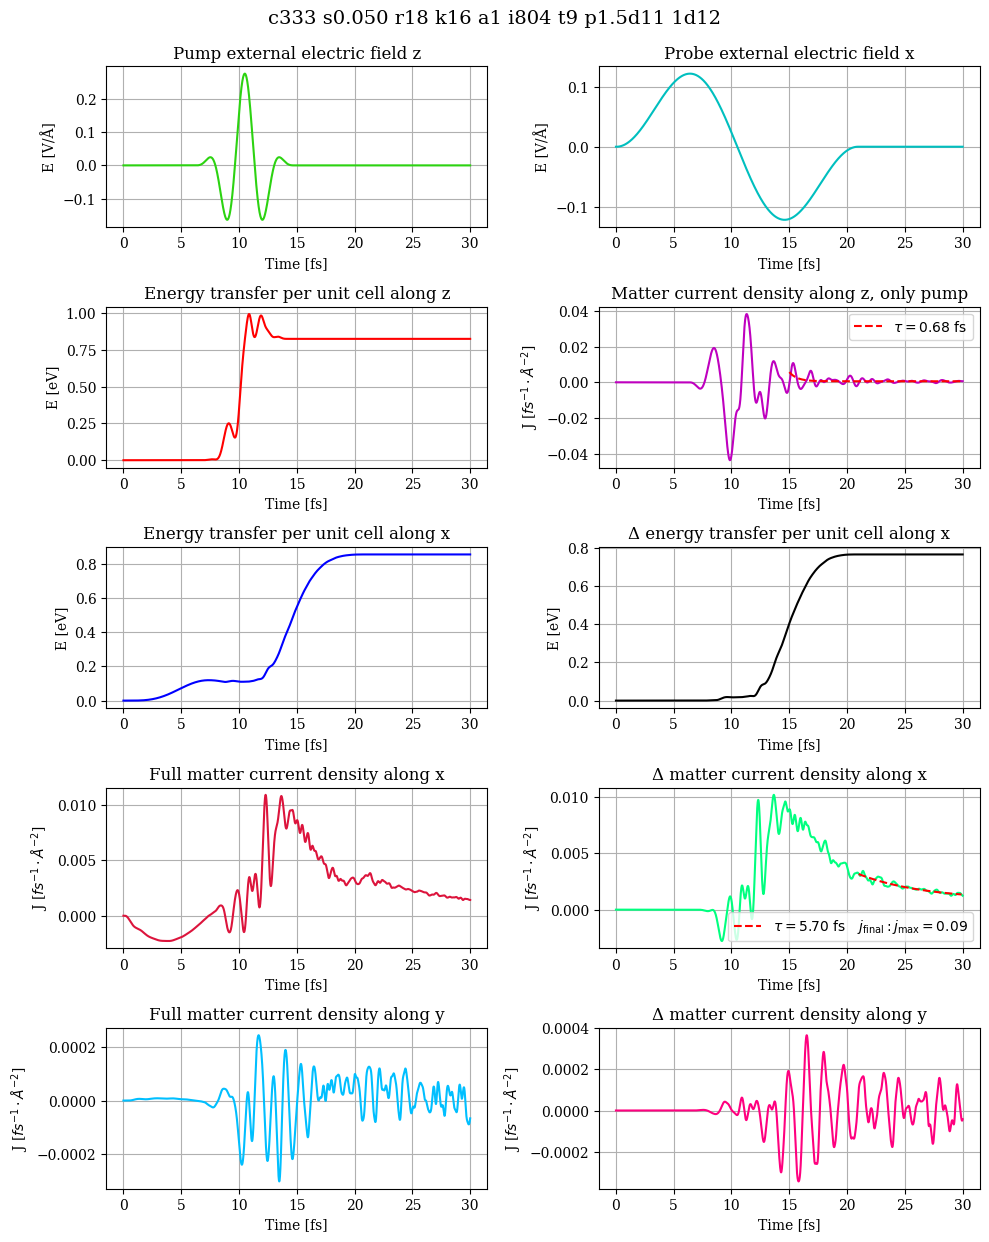

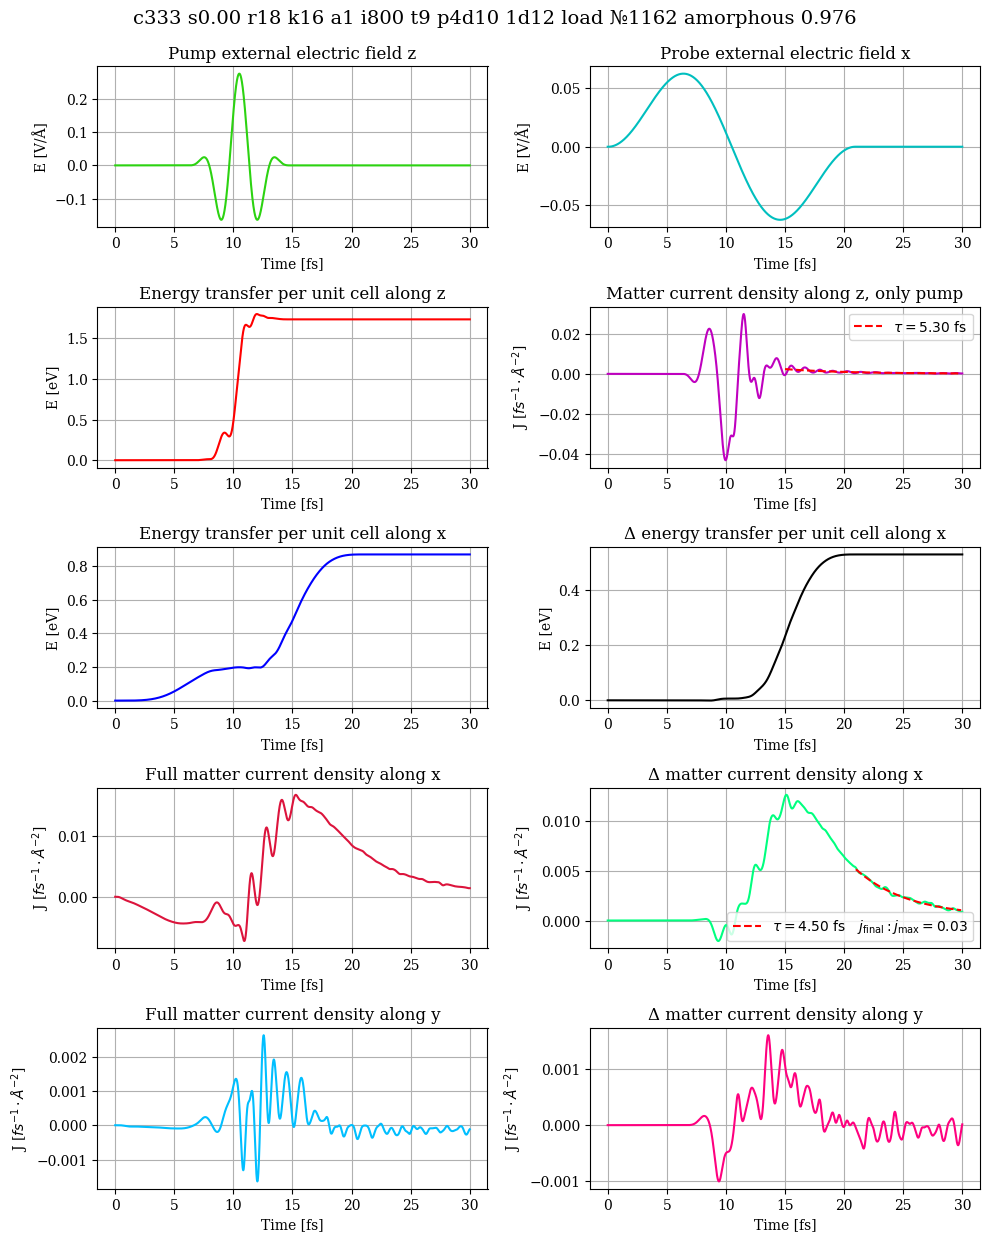

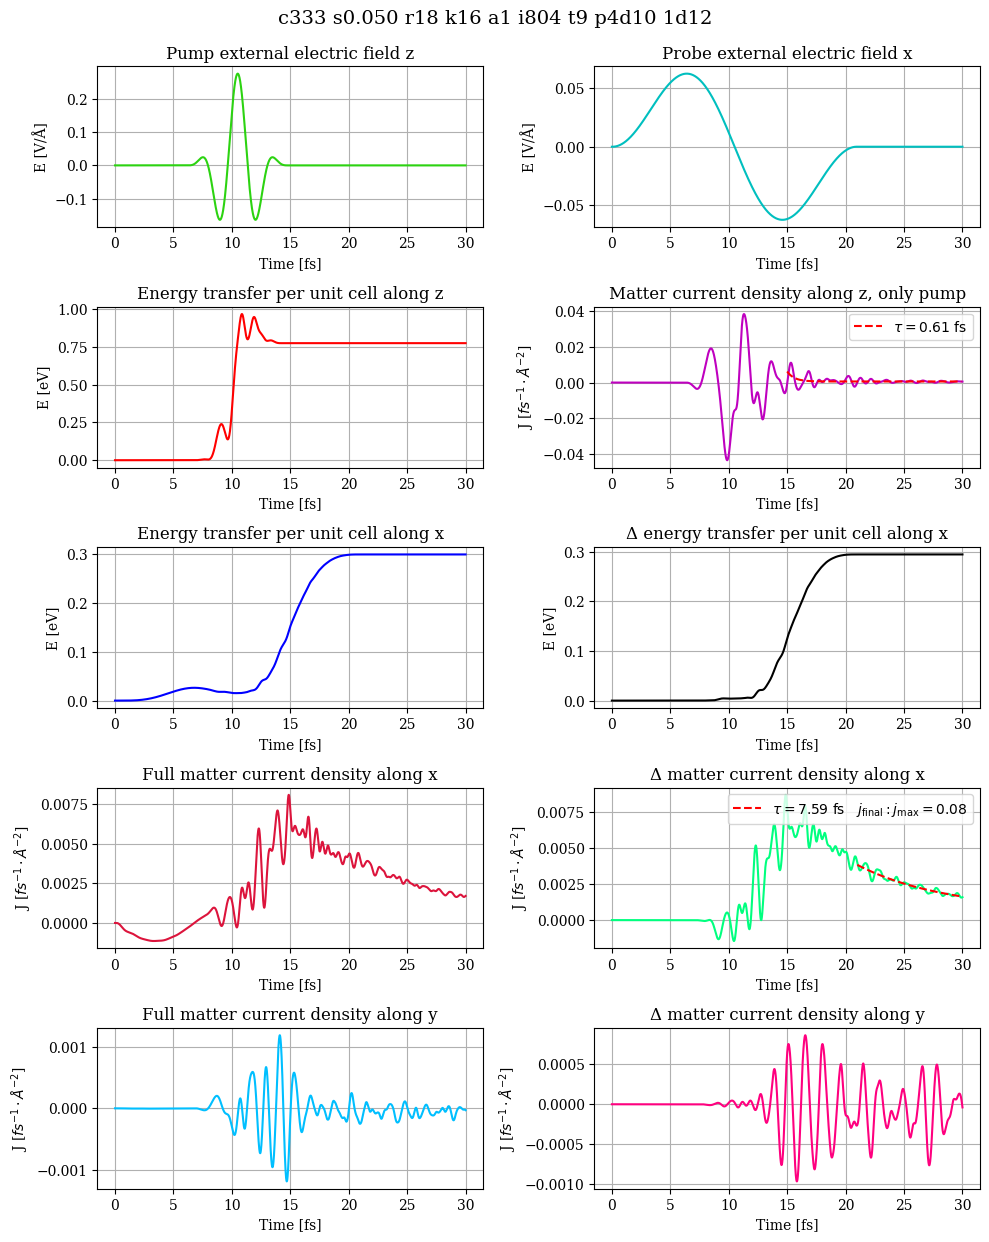

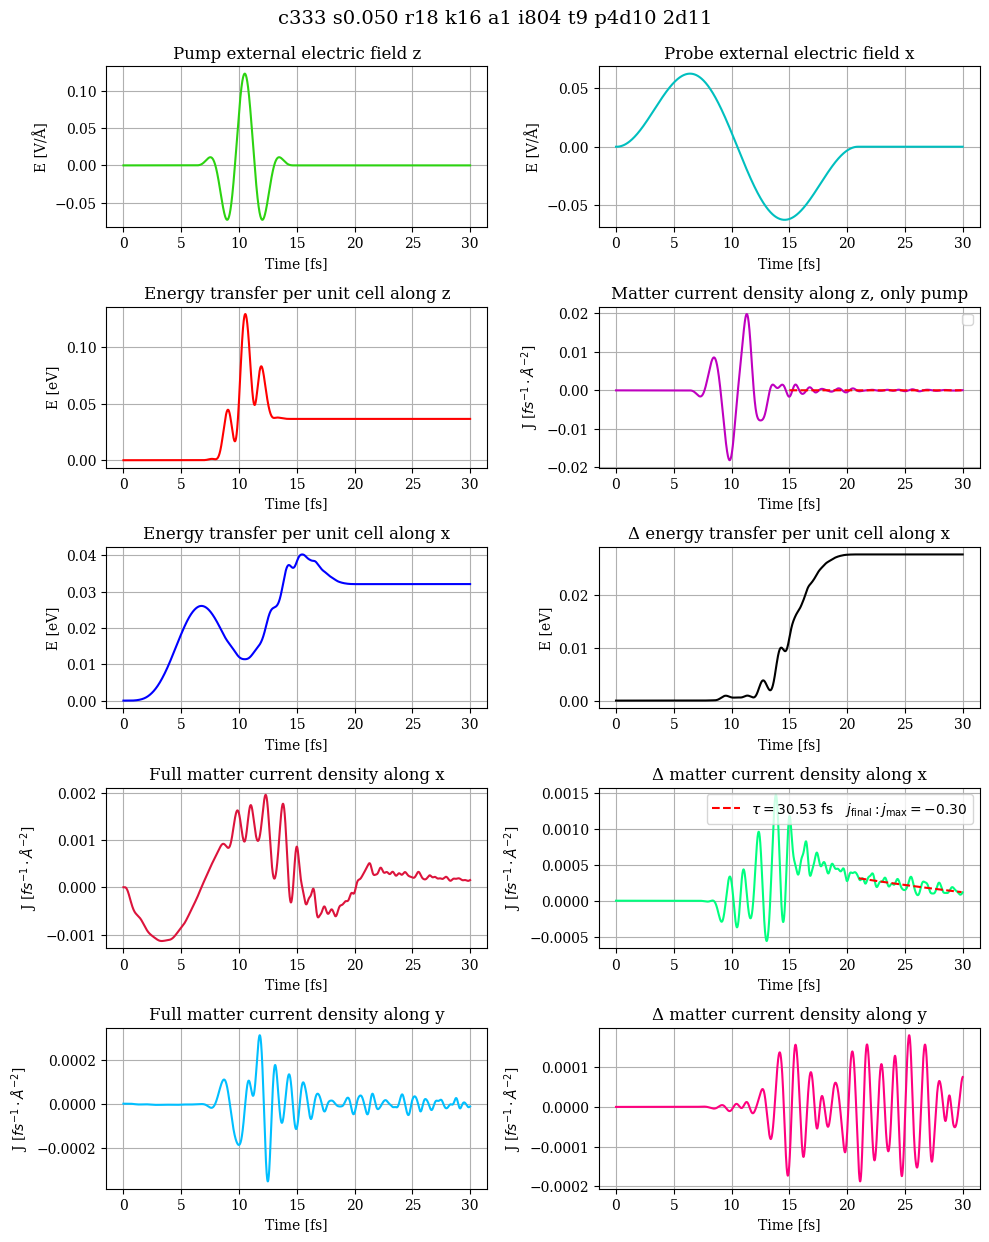

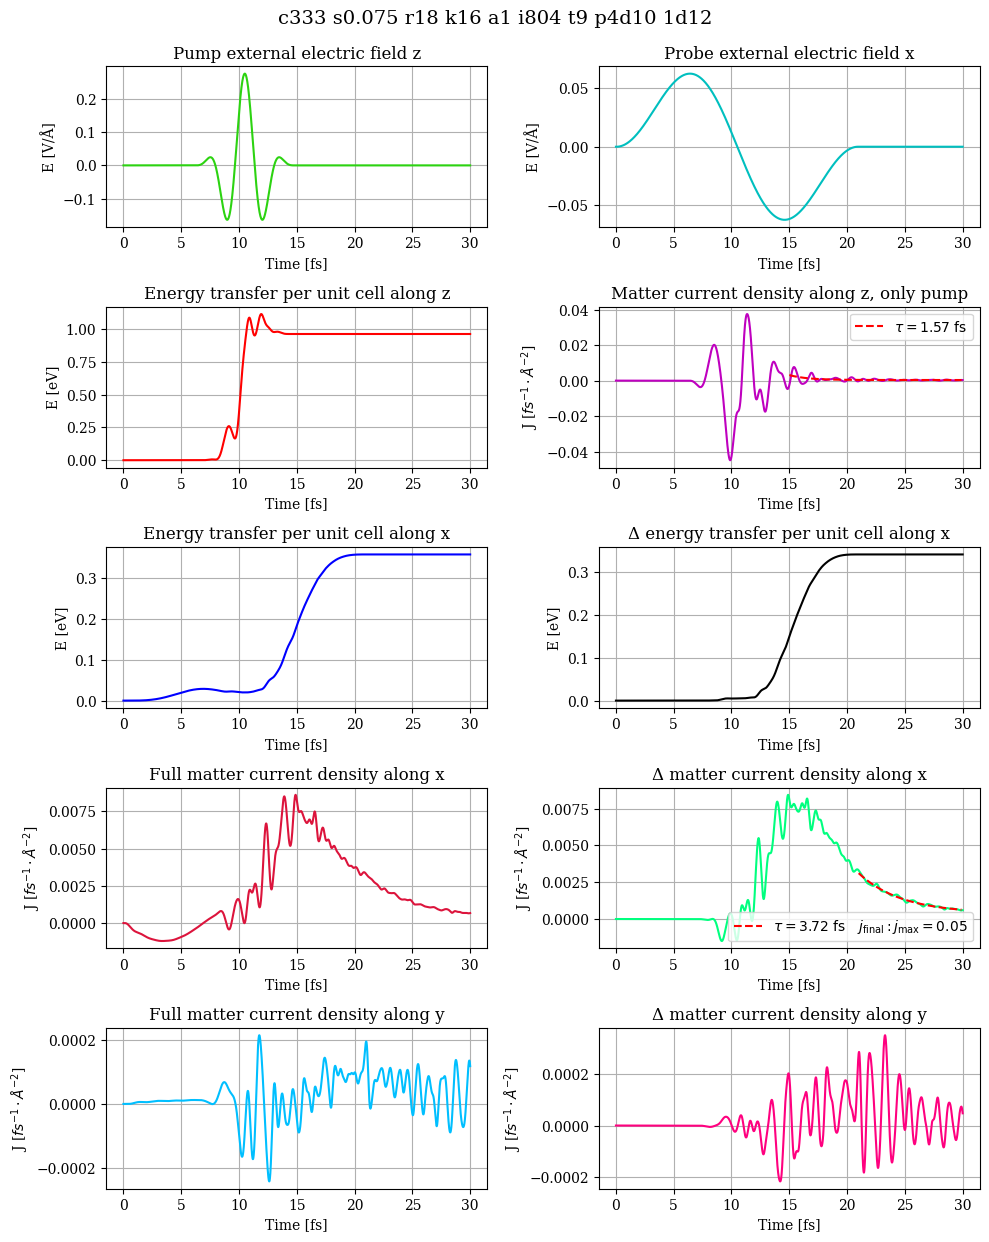

In [9]:
taus_exp_x = []

j=0
for folder in sorted_folders:
    j=j+1
    
    tau = plot_nonlinear_response_v4(folder, ax, j)
    taus_exp_x.append(tau)
    print("For " + folder + " all plots for current&energy are completed")

print(" ")

## energy & current plots

For c333_s0.050_r18_k16_a1_i804_t9_p1.5d11_1d12 energy&current plots are completed
For c333_s0.00_r18_k16_a1_i800_t9_p4d10_1d12_load_№1162_amorphous_0.976 energy&current plots are completed
For c333_s0.050_r18_k16_a1_i804_t9_p4d10_1d12 energy&current plots are completed
For c333_s0.050_r18_k16_a1_i804_t9_p4d10_2d11 energy&current plots are completed
For c333_s0.075_r18_k16_a1_i804_t9_p4d10_1d12 energy&current plots are completed
 


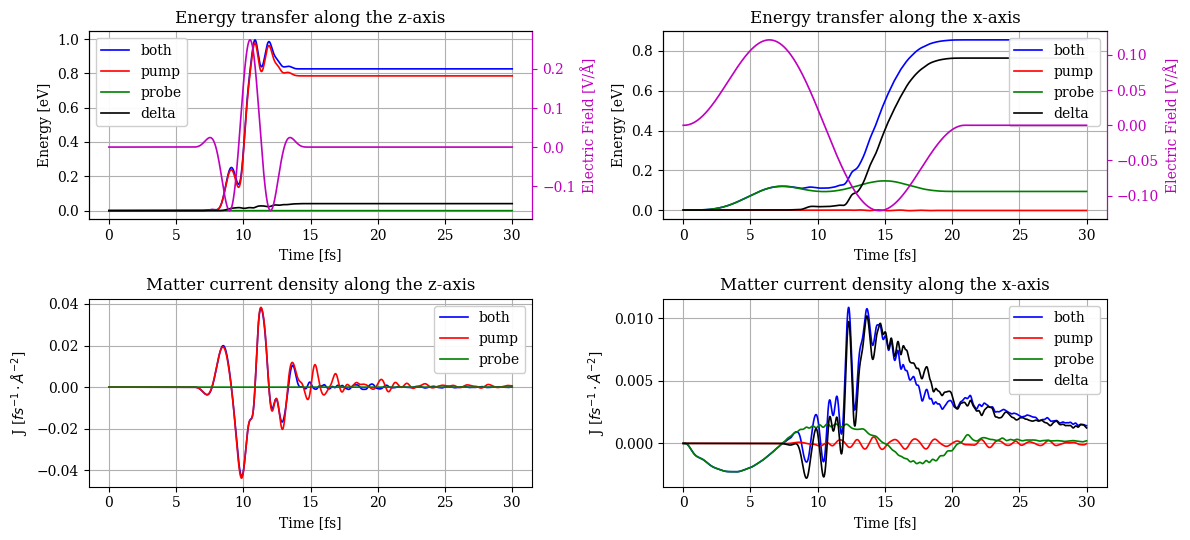

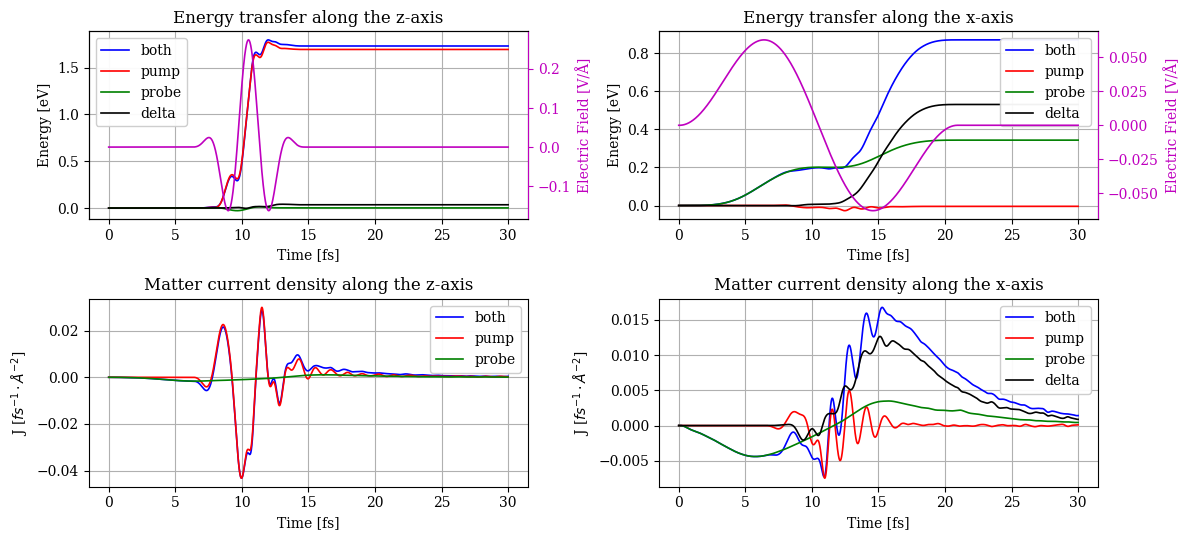

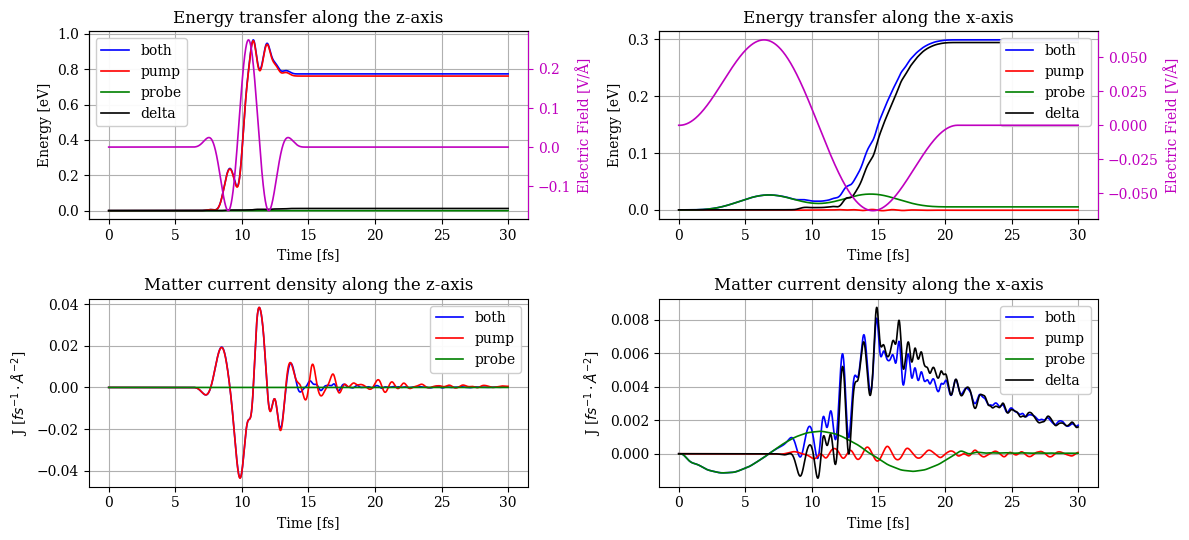

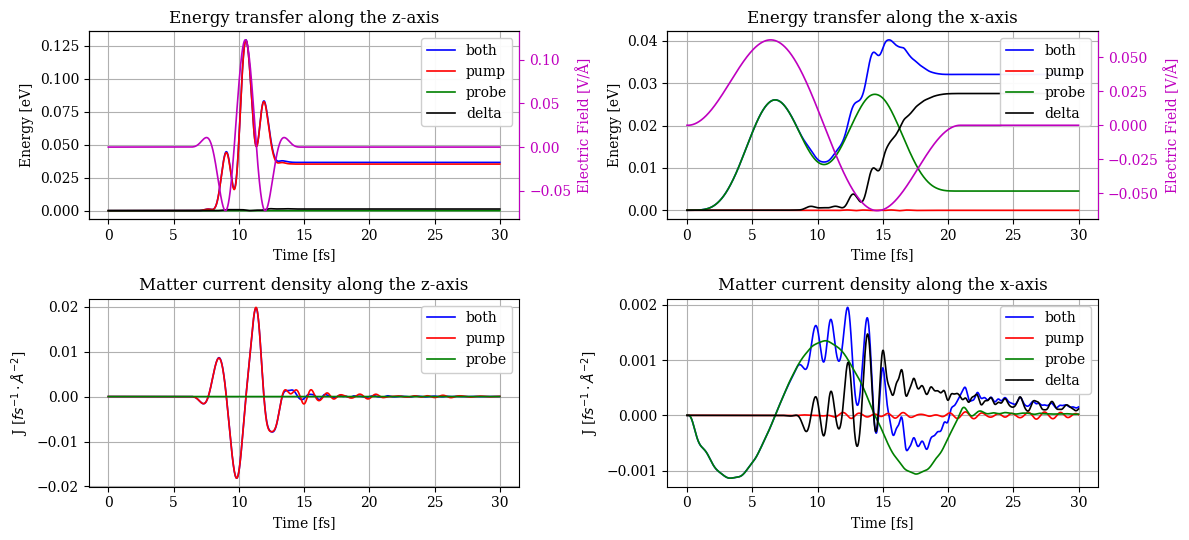

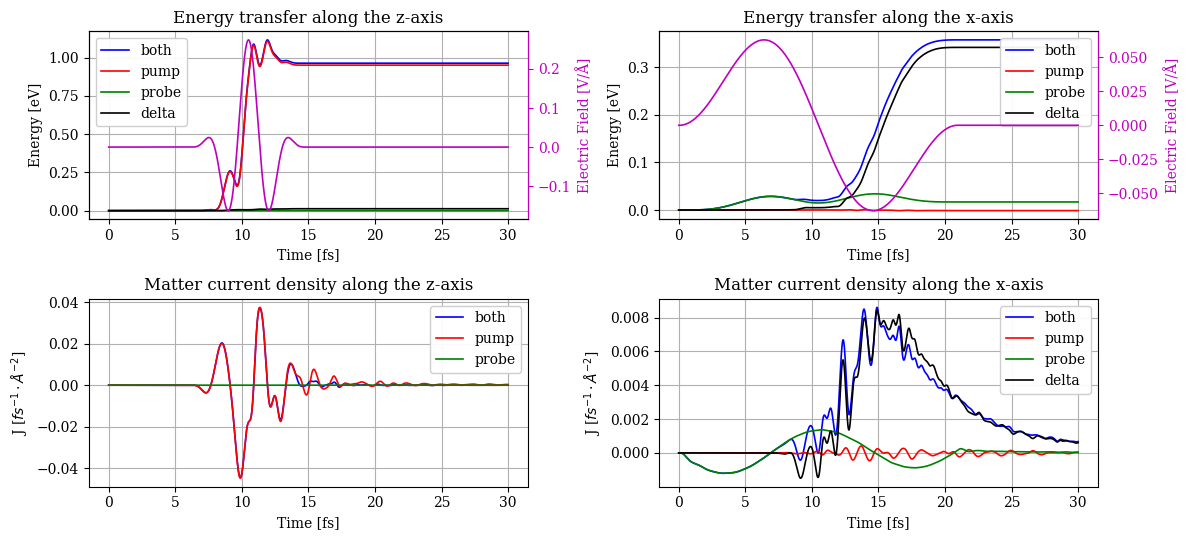

In [10]:
j=0
for folder in sorted_folders:

    j=j+1
    
    # Загрузка данных, пропуская строки с комментариями (начинаются с #)
    data_both = pd.read_csv(
        folder + '/both_pulses_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    data_pump = pd.read_csv(
        folder + '/pump_pulse_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    data_probe = pd.read_csv(
        folder + '/probe_pulse_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    
    # Назначим читаемые имена колонкам
    data_both.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']
    
    data_pump.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']
    
    data_probe.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']
    
    
    t = data_both['time_fs']
    
    
    Jm_both_z  =  data_both['Jm_z']
    Jm_pump_z  =  data_pump['Jm_z']
    Jm_probe_z =  data_probe['Jm_z']
    
    Jm_both_x  =  data_both['Jm_x']
    Jm_pump_x  =  data_pump['Jm_x']
    Jm_probe_x =  data_probe['Jm_x']
    
    Jm_both_y  =  data_both['Jm_y']
    Jm_pump_y  =  data_pump['Jm_y']
    Jm_probe_y =  data_probe['Jm_y']
    
    
    El_f_pump_z = data_both['E_ext_z']
    El_f_probe_x = data_both['E_ext_x']
    
    
    
    product_both_z = El_f_pump_z * Jm_both_z * volume
    # Разность по времени
    dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
    integral_both_z = np.cumsum(product_both_z * dt)
    
    product_pump_z = El_f_pump_z * Jm_pump_z * volume
    # Разность по времени
    dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
    integral_pump_z = np.cumsum(product_pump_z * dt)
    
    product_probe_z = El_f_pump_z * Jm_probe_z * volume
    # Разность по времени
    dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
    integral_probe_z = np.cumsum(product_probe_z * dt)
    
    product_delta_z = El_f_pump_z * (Jm_both_z - Jm_pump_z - Jm_probe_z) * volume
    # Разность по времени
    dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
    integral_delta_z = np.cumsum(product_delta_z * dt)
    
    
    
    product_both_x = El_f_probe_x * Jm_both_x * volume
    # Разность по времени
    dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
    integral_both_x = np.cumsum(product_both_x * dt)
    
    product_pump_x = El_f_probe_x * Jm_pump_x * volume
    # Разность по времени
    dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
    integral_pump_x = np.cumsum(product_pump_x * dt)
    
    product_probe_x = El_f_probe_x * Jm_probe_x * volume
    # Разность по времени
    dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
    integral_probe_x = np.cumsum(product_probe_x * dt)
    
    product_delta_x = El_f_probe_x * (Jm_both_x - Jm_pump_x - Jm_probe_x) * volume
    # Разность по времени
    dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
    integral_delta_x = np.cumsum(product_delta_x * dt)
    
    
    
    
    
    fig, axs = plt.subplots(2, 2, figsize=(12, 5.5))
    
    line_w=1.2
    alpha_val=1
    color_field = color = mcolors.to_rgba("m", alpha=alpha_val)
    framealpha_val=0.95
    
    ax1 = axs[0][1]
    
    ax1.plot(t, -integral_both_x, color='b', label='both', linewidth=line_w)
    ax1.plot(t, -integral_pump_x, color='r', label='pump', linewidth=line_w)
    ax1.plot(t, -integral_probe_x, color='green', label='probe', linewidth=line_w)
    ax1.plot(t, -integral_delta_x, color='black', label='delta', linewidth=line_w)
    ax1.set_xlabel('Time [fs]')
    ax1.set_ylabel('Energy [eV]')
    ax1.set_title('Energy transfer along the x-axis')
    ax1.legend(loc="upper right", framealpha=framealpha_val)
    ax1.grid()
    plt.tight_layout()
    
    
    ax1_right = ax1.twinx()
    ax1_right.plot(t, El_f_probe_x, color=color_field, label='probe field', linewidth=1.2)
    ax1_right.set_ylabel("Electric Field [V/Å]", color=color_field)
    ax1_right.tick_params(axis="y", colors=color_field)
    ax1_right.spines["right"].set_color(color_field)
    # ax1_right.legend()
    plt.tight_layout()
    
    
    
    ax2 = axs[0][0]
    
    ax2.plot(t, -integral_both_z, color='b', label='both', linewidth=line_w)
    ax2.plot(t, -integral_pump_z, color='r', label='pump', linewidth=line_w)
    ax2.plot(t, -integral_probe_z, color='green', label='probe', linewidth=line_w)
    ax2.plot(t, -integral_delta_z, color='black', label='delta', linewidth=line_w)
    ax2.set_xlabel('Time [fs]')
    ax2.set_ylabel('Energy [eV]')
    ax2.set_title('Energy transfer along the z-axis')
    ax2.legend(framealpha=framealpha_val)
    ax2.grid()
    plt.tight_layout()
    
    
    ax2_right = ax2.twinx()
    ax2_right.plot(t, El_f_pump_z, color=color_field, label='probe field', linewidth=1.2)
    ax2_right.set_ylabel("Electric Field [V/Å]", color=color_field)
    ax2_right.tick_params(axis="y", colors=color_field)
    ax2_right.spines["right"].set_color(color_field)
    # ax1_right.legend()
    plt.tight_layout()
    
    
    
    ax3 = axs[1][0]
    
    ax3.plot(t, Jm_both_z, color='b', label='both', linewidth=line_w)
    ax3.plot(t, Jm_pump_z, color='r', label='pump', linewidth=line_w)
    ax3.plot(t, Jm_probe_z, color='green', label='probe', linewidth=line_w)
    # ax3.plot(t, -integral_delta_z, color='black', label='delta')
    ax3.set_xlabel('Time [fs]')
    ax3.set_ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
    ax3.set_title('Matter current density along the z-axis')
    ax3.legend(framealpha=framealpha_val)
    ax3.grid()
    plt.tight_layout()
    
    
    # ax3_right = ax3.twinx()
    # ax3_right.plot(t, -El_f_pump_z, color='m', label='probe field')
    # ax3_right.set_ylabel("—Electric Field [V/Å]", color='m')
    # ax3_right.tick_params(axis="y", colors='m')
    # ax3_right.spines["right"].set_color('m')
    # # ax1_right.legend()
    # plt.tight_layout()
    
    
    
    ax4 = axs[1][1]
    
    ax4.plot(t, Jm_both_x, color='b', label='both', linewidth=line_w)
    ax4.plot(t, Jm_pump_x, color='r', label='pump', linewidth=line_w)
    ax4.plot(t, Jm_probe_x, color='green', label='probe', linewidth=line_w)
    ax4.plot(t, (Jm_both_x-Jm_pump_x-Jm_probe_x), color='black', label='delta', linewidth=line_w)
    ax4.set_xlabel('Time [fs]')
    ax4.set_ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
    ax4.set_title('Matter current density along the x-axis')
    ax4.legend(framealpha=framealpha_val)
    ax4.grid()
    plt.tight_layout()
    
    # ax4_right = ax4.twinx()
    # ax4_right.plot(t, -El_f_pump_z, color='m', label='probe field')
    # ax4_right.set_ylabel("—Electric Field [V/Å]", color='m')
    # ax4_right.tick_params(axis="y", colors='m')
    # ax4_right.spines["right"].set_color('m')
    # # ax1_right.legend()
    # plt.tight_layout()
    
    
    
    plt.savefig("all_data/current_energy/ims/energy_current/png/" + str(j)+ '_energy_current_' + folder + ".png", dpi=200)
    plt.savefig("all_data/current_energy/ims/energy_current/pdf/" + str(j)+ '_energy_current_' + folder + ".pdf", bbox_inches="tight")

    print("For " + folder + " energy&current plots are completed")

print(" ")

## current & energy data

In [11]:
j=0
for folder in sorted_folders:

    j=j+1
    
    # Загрузка данных, пропуская строки с комментариями (начинаются с #)
    data_both = pd.read_csv(
        folder + '/both_pulses_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    data_pump = pd.read_csv(
        folder + '/pump_pulse_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    data_probe = pd.read_csv(
        folder + '/probe_pulse_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    
    # Назначим читаемые имена колонкам
    data_both.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']
    
    data_pump.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']
    
    data_probe.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']
    
    
    t = data_both['time_fs']
    
    
    Jm_both_z  =  data_both['Jm_z']
    Jm_pump_z  =  data_pump['Jm_z']
    Jm_probe_z =  data_probe['Jm_z']
    
    Jm_both_x  =  data_both['Jm_x']
    Jm_pump_x  =  data_pump['Jm_x']
    Jm_probe_x =  data_probe['Jm_x']
    
    Jm_both_y  =  data_both['Jm_y']
    Jm_pump_y  =  data_pump['Jm_y']
    Jm_probe_y =  data_probe['Jm_y']
    
    
    El_f_pump_z = data_both['E_ext_z']
    El_f_probe_x = data_both['E_ext_x']
    
    
    
    product_both_z = El_f_pump_z * Jm_both_z * volume
    # Разность по времени
    dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
    integral_both_z = np.cumsum(product_both_z * dt)
    
    product_pump_z = El_f_pump_z * Jm_pump_z * volume
    # Разность по времени
    dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
    integral_pump_z = np.cumsum(product_pump_z * dt)
    
    product_probe_z = El_f_pump_z * Jm_probe_z * volume
    # Разность по времени
    dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
    integral_probe_z = np.cumsum(product_probe_z * dt)
    
    product_delta_z = El_f_pump_z * (Jm_both_z - Jm_pump_z - Jm_probe_z) * volume
    # Разность по времени
    dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
    integral_delta_z = np.cumsum(product_delta_z * dt)
    
    
    
    product_both_x = El_f_probe_x * Jm_both_x * volume
    # Разность по времени
    dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
    integral_both_x = np.cumsum(product_both_x * dt)
    
    product_pump_x = El_f_probe_x * Jm_pump_x * volume
    # Разность по времени
    dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
    integral_pump_x = np.cumsum(product_pump_x * dt)
    
    product_probe_x = El_f_probe_x * Jm_probe_x * volume
    # Разность по времени
    dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
    integral_probe_x = np.cumsum(product_probe_x * dt)
    
    product_delta_x = El_f_probe_x * (Jm_both_x - Jm_pump_x - Jm_probe_x) * volume
    # Разность по времени
    dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
    integral_delta_x = np.cumsum(product_delta_x * dt)
    
    
    
    
    
    each_num=10
    
    current_energy_array=np.array([ t[::each_num], El_f_pump_z[::each_num], El_f_probe_x[::each_num],
                                    Jm_both_z[::each_num], Jm_pump_z[::each_num], Jm_probe_z[::each_num],
                                    Jm_both_y[::each_num], Jm_pump_y[::each_num], Jm_probe_y[::each_num],
                                    Jm_both_x[::each_num], Jm_pump_x[::each_num], Jm_probe_x[::each_num], 
                                    -integral_both_z[::each_num], -integral_pump_z[::each_num], -integral_probe_z[::each_num],
                                    -integral_both_x[::each_num], -integral_pump_x[::each_num], -integral_probe_x[::each_num]
                                    ])
    
    columns = ["time",  "El_f_pump_z", "El_f_probe_x",
               "Jm_both_z", "Jm_pump_z", "Jm_probe_z",
               "Jm_both_y", "Jm_pump_y", "Jm_probe_y", 
               "Jm_both_x", "Jm_pump_x", "Jm_probe_x", 
               "En_both_z", "En_pump_z", "En_probe_z", 
               "En_both_x", "En_pump_x", "En_probe_x"]
    df = pd.DataFrame(current_energy_array.T, columns=columns)
    
    
    df.to_csv("all_data/current_energy/data/" + str(j)+ "_current_energy_data_" + folder + ".csv", index=False)
    
    with open("all_data/current_energy/data/" + str(j)+ "_current_energy_data_" + folder + ".csv", "w") as f:
        f.write("# Units: Time [fs], Current Jm [1/fs*Angstrom^2], Electric field El_f[V/Angstrom], Energy En[eV]\n")
        df.to_csv(f, index=False)
    
    print("For " + folder + " current&energy data saving in csv format is completed")

print(" ")
    # df_read = pd.read_csv("current_data.csv", comment="#")
    # df_read
    
    # plt.savefig("all_data/current_energy/ims/energy_current/png/" + str(j)+ '_' + folder + ".png", dpi=200)

For c333_s0.050_r18_k16_a1_i804_t9_p1.5d11_1d12 current&energy data saving in csv format is completed
For c333_s0.00_r18_k16_a1_i800_t9_p4d10_1d12_load_№1162_amorphous_0.976 current&energy data saving in csv format is completed
For c333_s0.050_r18_k16_a1_i804_t9_p4d10_1d12 current&energy data saving in csv format is completed
For c333_s0.050_r18_k16_a1_i804_t9_p4d10_2d11 current&energy data saving in csv format is completed
For c333_s0.075_r18_k16_a1_i804_t9_p4d10_1d12 current&energy data saving in csv format is completed
 


## hhg plots

For c333_s0.050_r18_k16_a1_i804_t9_p1.5d11_1d12 hhg plots are completed
For c333_s0.00_r18_k16_a1_i800_t9_p4d10_1d12_load_№1162_amorphous_0.976 hhg plots are completed
For c333_s0.050_r18_k16_a1_i804_t9_p4d10_1d12 hhg plots are completed
For c333_s0.050_r18_k16_a1_i804_t9_p4d10_2d11 hhg plots are completed
For c333_s0.075_r18_k16_a1_i804_t9_p4d10_1d12 hhg plots are completed
 


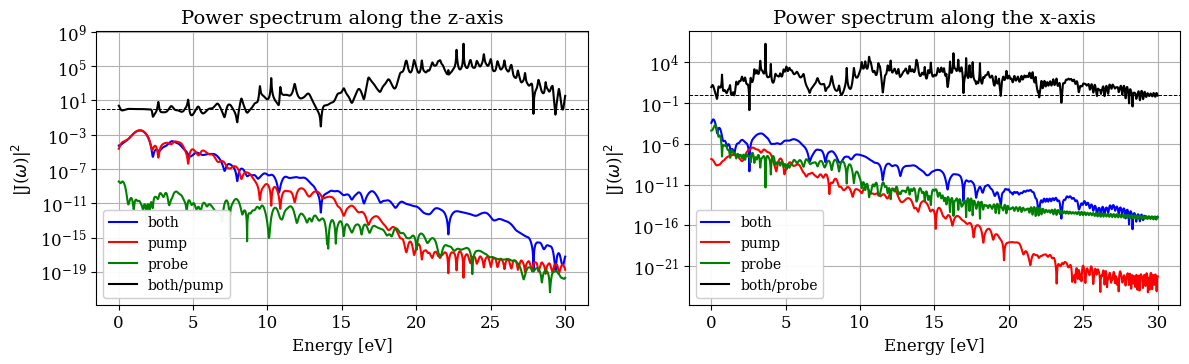

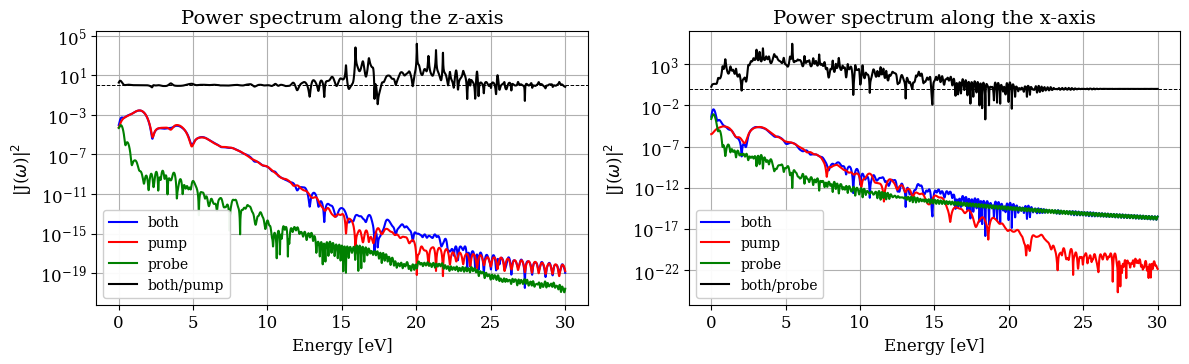

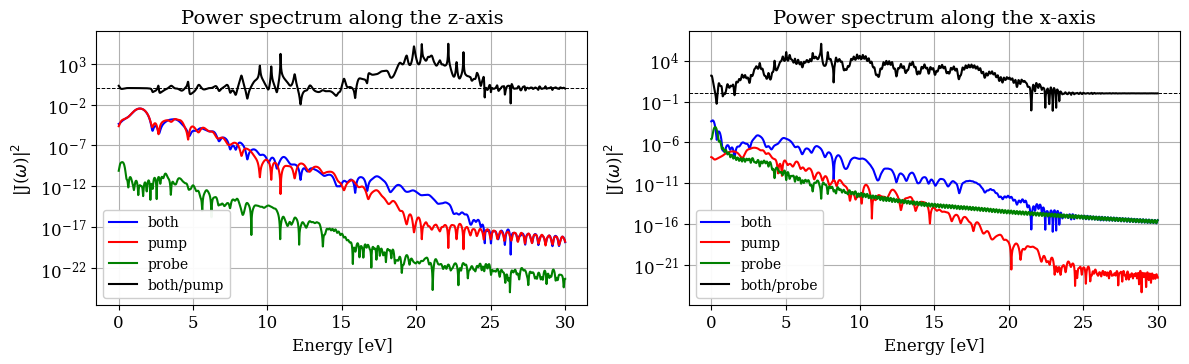

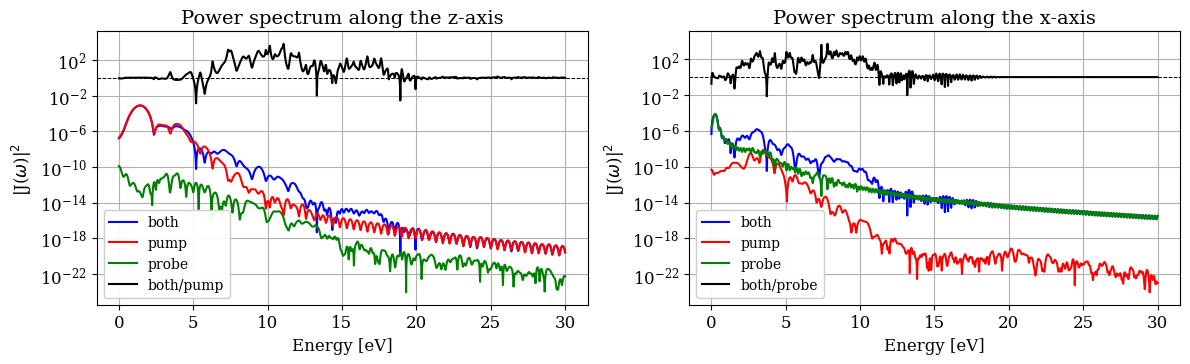

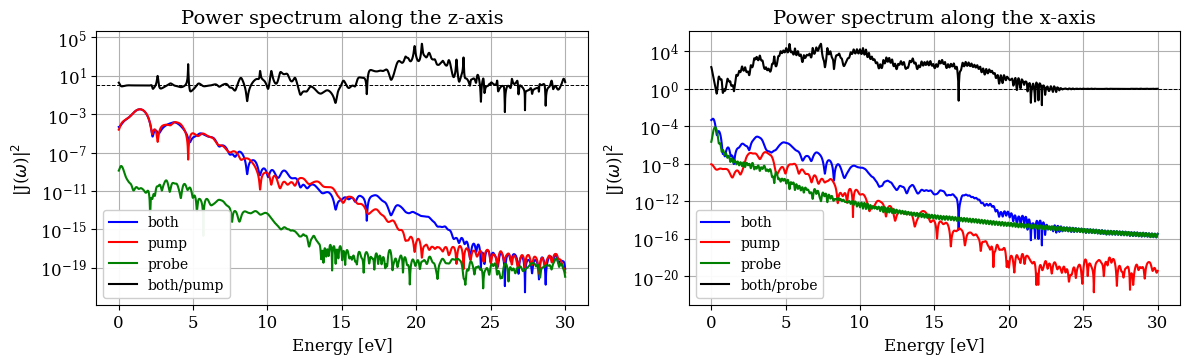

In [12]:
j=0
for folder in sorted_folders:
    
    j=j+1
    
    # Загрузка данных, пропуская строки с комментариями (начинаются с #)
    pulse_data_both = pd.read_csv(
        folder + '/both_pulses_pulse.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    pulse_data_pump = pd.read_csv(
        folder + '/pump_pulse_pulse.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    pulse_data_probe = pd.read_csv(
        folder + '/probe_pulse_pulse.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    
    pulse_data_both.columns = [
        'Energy_eV',
    
        'Re_Jm_x', 'Re_Jm_y', 'Re_Jm_z',
        'Im_Jm_x', 'Im_Jm_y', 'Im_Jm_z',
        'Abs2_Jm_x', 'Abs2_Jm_y', 'Abs2_Jm_z',
    
        'Re_El_f_Ext_x', 'Re_El_f_Ext_y', 'Re_El_f_Ext_z',
        'Im_El_f_Ext_x', 'Im_El_f_Ext_y', 'Im_El_f_Ext_z',
        'Abs2_El_f_Ext_x', 'Abs2_El_f_Ext_y', 'Abs2_El_f_Ext_z',
    
        'Re_El_f_Tot_x', 'Re_El_f_Tot_y', 'Re_El_f_Tot_z',
        'Im_El_f_Tot_x', 'Im_El_f_Tot_y', 'Im_El_f_Tot_z',
        'Abs2_El_f_Tot_x', 'Abs2_El_f_Tot_y', 'Abs2_El_f_Tot_z'
    ]
    
    pulse_data_pump.columns  = pulse_data_both.columns
    
    pulse_data_probe.columns = pulse_data_both.columns
    
    
    energies = pulse_data_both['Energy_eV']
    
    
    Abs2_Jm_both_z  =  pulse_data_both['Abs2_Jm_z']
    Abs2_Jm_pump_z  =  pulse_data_pump['Abs2_Jm_z']
    Abs2_Jm_probe_z =  pulse_data_probe['Abs2_Jm_z']
    
    Abs2_Jm_both_x  =  pulse_data_both['Abs2_Jm_x']
    Abs2_Jm_pump_x  =  pulse_data_pump['Abs2_Jm_x']
    Abs2_Jm_probe_x =  pulse_data_probe['Abs2_Jm_x']
    
    Abs2_Jm_both_y  =  pulse_data_both['Abs2_Jm_y']
    Abs2_Jm_pump_y  =  pulse_data_pump['Abs2_Jm_y']
    Abs2_Jm_probe_y =  pulse_data_probe['Abs2_Jm_y']
    
    
    
    fig, axs = plt.subplots(1, 2, figsize=(12, 3.75))
    
    line_w=1.5
    alpha_val=1
    color_field = color = mcolors.to_rgba("m", alpha=alpha_val)
    framealpha_val=0.95
    
    ax1 = axs[0]
    
    
    ax1.axhline(y=1.0, color='black', linestyle='--', linewidth=0.7)
    
    ax1.plot(energies, Abs2_Jm_both_z, color='b', label='both', linewidth=line_w)
    ax1.plot(energies, Abs2_Jm_pump_z, color='r', label='pump', linewidth=line_w)
    ax1.plot(energies, Abs2_Jm_probe_z, color='green', label='probe', linewidth=line_w)
    ax1.plot(energies, Abs2_Jm_both_z/Abs2_Jm_pump_z, color='black', label='both/pump', linewidth=line_w)
    ax1.set_xlabel('Energy [eV]', fontsize=12)
    ax1.set_ylabel(r'|J($\omega$)|$^2$', fontsize=12)
    ax1.set_title('Power spectrum along the z-axis', fontsize=14)
    ax1.tick_params(axis='both', labelsize=12)
    ax1.legend(loc="lower left", framealpha=framealpha_val, fontsize=10)
    ax1.set_yscale('log')
    ax1.grid()
    plt.tight_layout()
    
    
    
    ax2 = axs[1]

    ax2.axhline(y=1.0, color='black', linestyle='--', linewidth=0.7)
    
    ax2.plot(energies, Abs2_Jm_both_x, color='b', label='both', linewidth=line_w)
    ax2.plot(energies, Abs2_Jm_pump_x, color='r', label='pump', linewidth=line_w)
    ax2.plot(energies, Abs2_Jm_probe_x, color='green', label='probe', linewidth=line_w)
    ax2.plot(energies, Abs2_Jm_both_x/Abs2_Jm_probe_x, color='black', label='both/probe', linewidth=line_w)
    # ax2.plot(energies, Abs2_Jm_both_z/Abs2_Jm_pump_z, color='black', label='both/pump', linewidth=line_w)
    ax2.set_xlabel('Energy [eV]', fontsize=12)
    ax2.set_ylabel(r'|J($\omega$)|$^2$', fontsize=12)
    ax2.set_title('Power spectrum along the x-axis', fontsize=14)
    ax2.tick_params(axis='both', labelsize=12)
    ax2.legend(loc="lower left", framealpha=framealpha_val)
    ax2.set_yscale('log')
    ax2.grid()
    plt.tight_layout()
    
    
    plt.savefig("all_data/hhg/ims/png/" + str(j)+ '_hhg_' + folder + ".png", dpi=200)
    plt.savefig("all_data/hhg/ims/pdf/" + str(j)+ '_hhg_' + folder + ".pdf", bbox_inches="tight")
    
    print("For " + folder + " hhg plots are completed")

print(" ")

## hhg data

In [13]:
j=0
for folder in sorted_folders:

    j=j+1
    
    # Загрузка данных, пропуская строки с комментариями (начинаются с #)
    pulse_data_both = pd.read_csv(
        folder + '/both_pulses_pulse.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    pulse_data_pump = pd.read_csv(
        folder + '/pump_pulse_pulse.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    pulse_data_probe = pd.read_csv(
        folder + '/probe_pulse_pulse.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    
    pulse_data_both.columns = [
        'Energy_eV',
    
        'Re_Jm_x', 'Re_Jm_y', 'Re_Jm_z',
        'Im_Jm_x', 'Im_Jm_y', 'Im_Jm_z',
        'Abs2_Jm_x', 'Abs2_Jm_y', 'Abs2_Jm_z',
    
        'Re_El_f_Ext_x', 'Re_El_f_Ext_y', 'Re_El_f_Ext_z',
        'Im_El_f_Ext_x', 'Im_El_f_Ext_y', 'Im_El_f_Ext_z',
        'Abs2_El_f_Ext_x', 'Abs2_El_f_Ext_y', 'Abs2_El_f_Ext_z',
    
        'Re_El_f_Tot_x', 'Re_El_f_Tot_y', 'Re_El_f_Tot_z',
        'Im_El_f_Tot_x', 'Im_El_f_Tot_y', 'Im_El_f_Tot_z',
        'Abs2_El_f_Tot_x', 'Abs2_El_f_Tot_y', 'Abs2_El_f_Tot_z'
    ]
    
    pulse_data_pump.columns  = pulse_data_both.columns
    
    pulse_data_probe.columns = pulse_data_both.columns
    
    
    #both
    pulse_data_both_cut = pulse_data_both[pulse_data_both.columns[:10]]
    pulse_data_both_cut.to_csv("all_data/hhg/data/" + str(j)+ "_hhg_data_both_pulses_" + folder + ".csv", index=False)
    
    with open("all_data/hhg/data/" + str(j)+ "_hhg_data_both_pulses_" + folder + ".csv", "w") as f:
        f.write("# Fourier-transform spectra:\n")
        f.write("# Units: energy[eV], Jm[1/Angstrom^2], |Jm|^2 [1/Angstrom^4]\n")
        pulse_data_both_cut.to_csv(f, index=False)
    
    
    #pump
    pulse_data_pump_cut = pulse_data_pump[pulse_data_pump.columns[:10]]
    pulse_data_pump_cut.to_csv("all_data/hhg/data/" + str(j)+ "_hhg_data_pump_pulse_" + folder + ".csv", index=False)
    
    with open("all_data/hhg/data/" + str(j)+ "_hhg_data_pump_pulse_" + folder + ".csv", "w") as f:
        f.write("# Fourier-transform spectra:\n")
        f.write("# Units: energy[eV], Jm[1/Angstrom^2], |Jm|^2 [1/Angstrom^4]\n")
        pulse_data_pump_cut.to_csv(f, index=False)
    
    
    #probe
    pulse_data_probe_cut = pulse_data_probe[pulse_data_probe.columns[:10]]
    pulse_data_probe_cut.to_csv("all_data/hhg/data/" + str(j)+ "_hhg_data_probe_pulse_" + folder + ".csv", index=False)
    
    with open("all_data/hhg/data/" + str(j)+ "_hhg_data_probe_pulse_" + folder + ".csv", "w") as f:
        f.write("# Fourier-transform spectra:\n")
        f.write("# Units: energy[eV], Jm[1/Angstrom^2], |Jm|^2 [1/Angstrom^4]\n")
        pulse_data_probe_cut.to_csv(f, index=False)
    
    
    print("For " + folder + " hhg csv data saving is completed")

print(" ")

For c333_s0.050_r18_k16_a1_i804_t9_p1.5d11_1d12 hhg csv data saving is completed
For c333_s0.00_r18_k16_a1_i800_t9_p4d10_1d12_load_№1162_amorphous_0.976 hhg csv data saving is completed
For c333_s0.050_r18_k16_a1_i804_t9_p4d10_1d12 hhg csv data saving is completed
For c333_s0.050_r18_k16_a1_i804_t9_p4d10_2d11 hhg csv data saving is completed
For c333_s0.075_r18_k16_a1_i804_t9_p4d10_1d12 hhg csv data saving is completed
 


## fid

In [40]:
def coherence_time(Y, dt) -> float:
    r"""
    Given a signal Y(t) on an equidistant grid, the function estimates the coherence time.

    The function implements Mandel's coherence time. It calculates the autocorrelation
    function of the given signal, then it calculates the complex envelope of the
    autocorrelation function, and integrates the square of the normalized envelope from
    t=0 to the maximal time. The coherence time is twice the value of the integral.

    Args:
      Y: 1D array that represents the time-dependent signal on a regular grid.
      dt: Time step of the grid.

    Returns:
      the coherence time as a floating-point number.
    """
    ACF = scipy.signal.correlate(Y, Y, mode="full", method="direct") # autocorrelation function
    N = len(Y)
    # X = dt * np.arange(-(N - 1), N) # DEBUGGING
    ACF_envelope = np.abs(scipy.signal.envelope(ACF, residual=None))
    ACF_envelope /= np.max(ACF_envelope)
    i1 = N - 1 # np.flatnonzero(X >= 0)[0]
    # print("X[i1] =", X[i1]) # DEBUGGING
    return 2.0 * scipy.integrate.simpson(ACF_envelope[i1:]**2, dx=dt)

In [39]:
# coherence_time(fid_signal, 0.002)
# ACF = scipy.signal.correlate(fid_signal, fid_signal, mode="full", method="direct") # autocorrelation function
# ACF_envelope = np.abs(scipy.signal.envelope(ACF, residual=None))
# ACF_envelope /= np.max(ACF_envelope)

# plt.plot(abs(ACF)/max(ACF))
# plt.plot(ACF_envelope)

In [16]:
def find_halfcycle_maxima(t, y):
    """
    Находит координаты всех локальных максимумов:
    y'(t)=0 и y''(t)<0
    Возвращает массивы t_max, y_max
    """
    
    # первая и вторая производные
    dy = np.gradient(y, t)
    d2y = np.gradient(dy, t)

    # условие смены знака производной + на -
    sign_change = np.where(
        (dy[:-1] > 0) & (dy[1:] <= 0)
    )[0]

    # фильтрация по второй производной < 0
    maxima_indices = [
        i for i in sign_change if d2y[i] < 0
    ]

    t_max = t[maxima_indices]
    y_max = y[maxima_indices]

    return np.array(t_max), np.array(y_max)

In [17]:
def exp_gauss(t, A, tau, t0, sigma, C):
    return A * np.exp(-t / tau) * np.exp(-(0*t)**2 / (2 * sigma**2)) + C


def fit_exp_gauss(t, y):
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)

    A0 = np.max(y) - np.min(y)
    tau0 = 2
    t0_0 = 0
    sigma0 = 1
    C0 = np.min(y)

    p0 = [A0, tau0, t0_0, sigma0, C0]

    popt, pcov = curve_fit(exp_gauss, t, y, p0=p0, maxfev=10000)

    return popt, pcov

In [18]:
def gaussian_convolve(y, sigma):
    """
    Свёртка массива y с гауссовым ядром.
    
    sigma — стандартное отклонение в точках.
    """
    y = np.asarray(y)
    
    # длина ядра (берём ±4σ)
    radius = int(4 * sigma)
    x = np.arange(-radius, radius + 1)
    
    # гауссово ядро
    kernel = np.exp(-x**2 / (2 * sigma**2))
    kernel /= kernel.sum()  # нормировка
    
    # линейная свёртка (без периодичности)
    y_smooth = np.convolve(y, kernel, mode='same')
    
    return y_smooth

In [41]:
def fourier_plot(fid_signal, convolve_val):

    N = len(fid_signal)
    
    # убираем среднее (рекомендовано)
    x = np.array(fid_signal)-np.mean(fid_signal)
    
    # FFT
    M=5
    xpad = np.pad(x, (0, (M-1)*len(x)))
    X = np.fft.rfft(xpad)
    freq = np.fft.rfftfreq(M*N, d=0.002)   # частота в 1/fs
    
    # ---- единственная физическая константа ----
    h_eV_fs = 4.135667696                # eV·fs
    E_eV = h_eV_fs * freq
    
    # амплитуда
    A = np.abs(X)
    
    # график
    # plt.plot(E_eV, gaussian_convolve(A, convolve_val)/max(gaussian_convolve(A, convolve_val)), color='b')
    # plt.xlabel("Energy (eV)")
    # plt.ylabel("|FFT|")
    # plt.ylim(0, 1.1)
    # plt.xlim(1, E_eV[-1]/120)
    # plt.grid()
    # plt.show()
    A = A[:int(110*M/4)]

    return E_eV[:int(110*M/4)], gaussian_convolve(A, convolve_val)/max(gaussian_convolve(A, convolve_val))

In [56]:
max(fid_peak_vals[-4:])

min(y_fit+max(fid_peak_vals[-4:])-C)

0.00026118179770423506

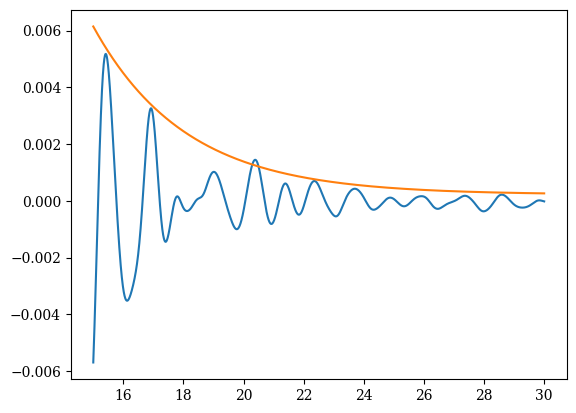

In [55]:
# plt.plot(t[m0_cut_4:], (Jm_pump_z[m0_cut_4:]-j_fit_full)/(y_fit+max(fid_peak_vals[-4:])-C), color='m')
plt.plot(t[m0_cut_4:], Jm_pump_z[m0_cut_4:]-j_fit_full)
plt.plot(t[m0_cut_4:], y_fit+max(fid_peak_vals[-4:])-C)

For c333_s0.050_r18_k16_a1_i804_t9_p1.5d11_1d12 z-axis fid plots are completed
Mandel's time fot fid normalized signal 2.687008153647802
For c333_s0.050_r18_k16_a1_i804_t9_p1.5d11_1d12 z-axis fid data saving in csv format is completed
Mandel's coherence time: 1.6515007486372482
3.328459675739773
4.26194174014596
4.2006467724437755
3.663300513201763
3.1819444804004355
2.8107932009283605
2.516345847195975
2.274845177667076
2.0735195214397235
1.9042783797271856
Spectrum autocorrelation time: 
3.14310744896
1.741999999999999
13.153999999999998


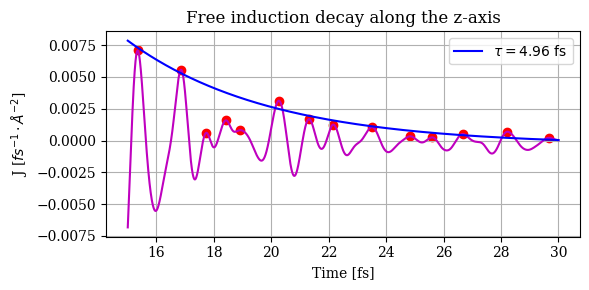

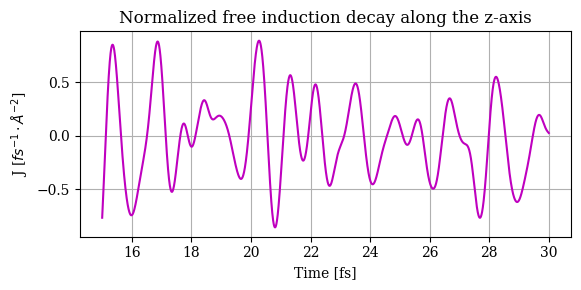

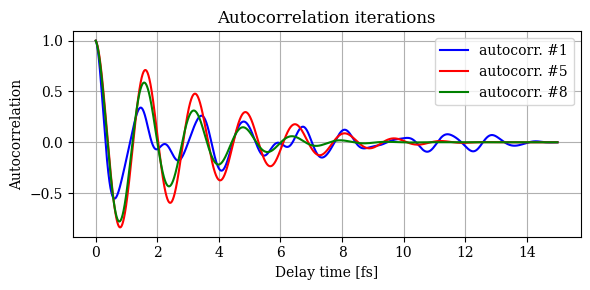

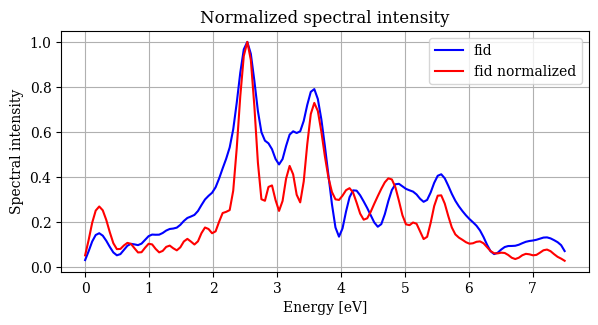

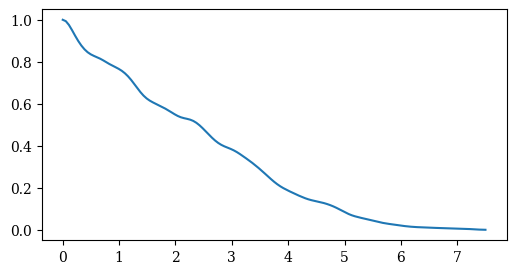

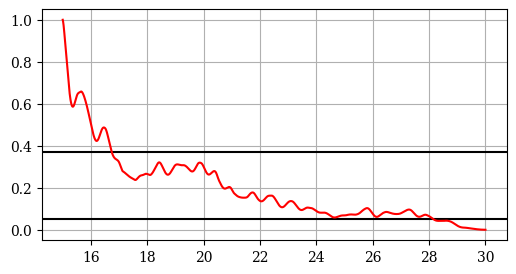

For c333_s0.00_r18_k16_a1_i800_t9_p4d10_1d12_load_№1162_amorphous_0.976 z-axis fid plots are completed
Mandel's time fot fid normalized signal 4.265841861843153
For c333_s0.00_r18_k16_a1_i800_t9_p4d10_1d12_load_№1162_amorphous_0.976 z-axis fid data saving in csv format is completed
Mandel's coherence time: 2.178133829492209
3.5348764757591513
3.7168439403301963
3.7887123967978305
3.6575644759386794
3.354379772207516
2.996068610444988
2.6599920791257112
2.371832551023358
2.132249028900373
1.9341536179633925
Spectrum autocorrelation time: 
3.3085341568
1.9120000000000008
11.275999999999998


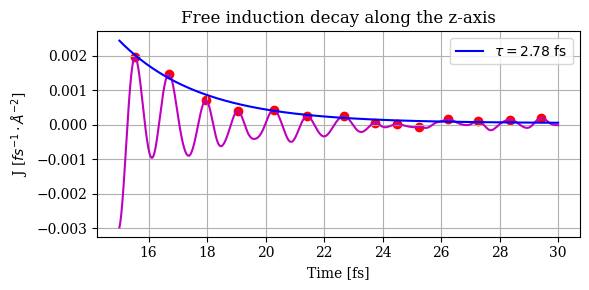

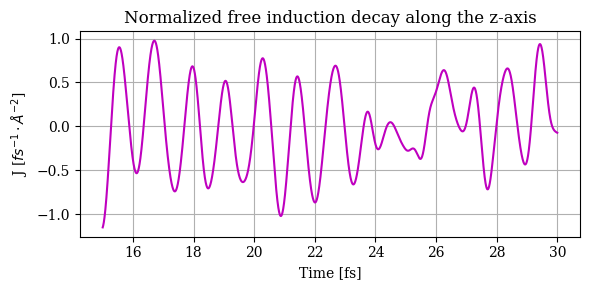

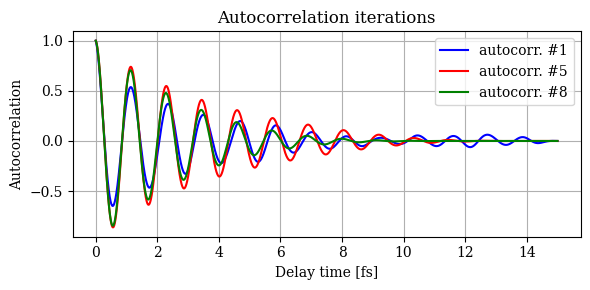

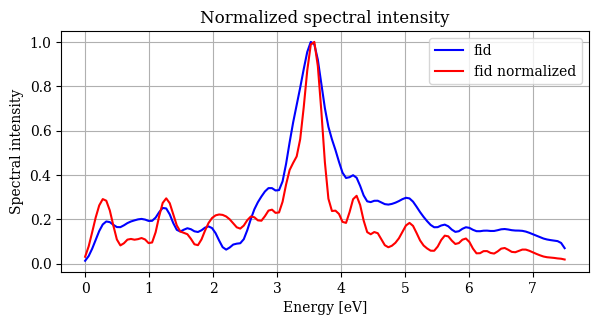

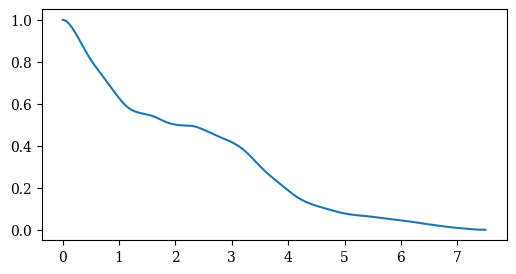

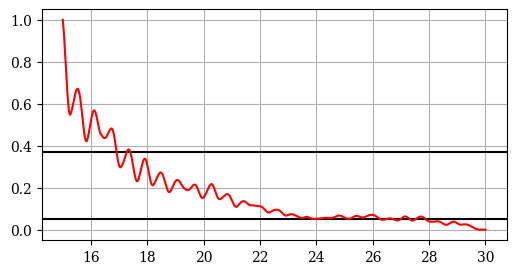

For c333_s0.050_r18_k16_a1_i804_t9_p4d10_1d12 z-axis fid plots are completed
Mandel's time fot fid normalized signal 2.010399838054839
For c333_s0.050_r18_k16_a1_i804_t9_p4d10_1d12 z-axis fid data saving in csv format is completed
Mandel's coherence time: 1.4640066692593394
2.1822044791464617
2.634457657786425
3.3015552524691287
3.589974034160987
3.2595073282822207
2.8587866573522303
2.5466096511615306
2.3039208467017853
2.1042262422942652
1.9345685661252816
Spectrum autocorrelation time: 
3.14310744896
1.7299999999999986
12.464


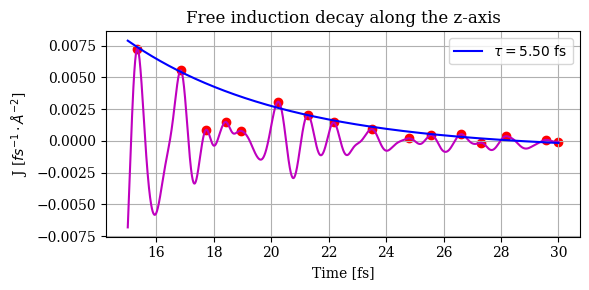

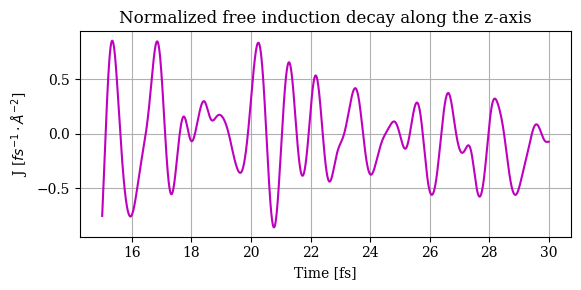

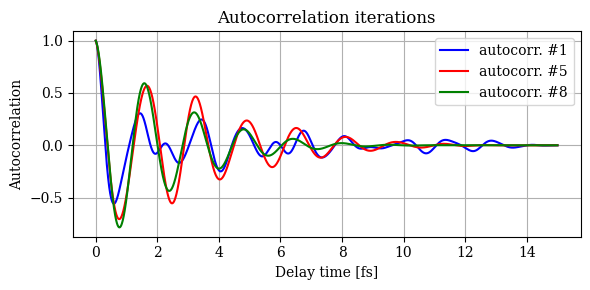

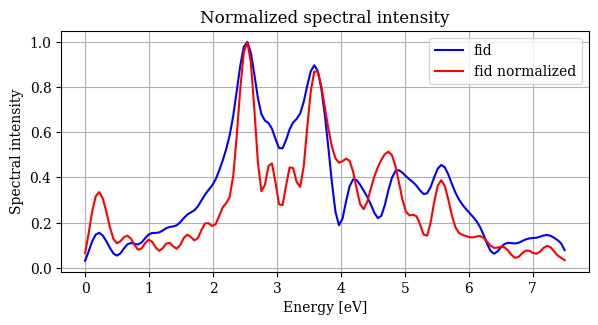

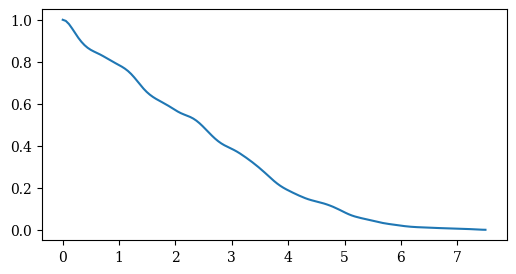

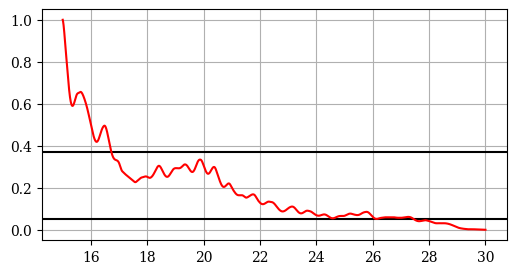

For c333_s0.050_r18_k16_a1_i804_t9_p4d10_2d11 z-axis fid plots are completed
Mandel's time fot fid normalized signal 3.7685283704010084
For c333_s0.050_r18_k16_a1_i804_t9_p4d10_2d11 z-axis fid data saving in csv format is completed
Mandel's coherence time: 2.2900251450168874
3.7098344447116176
4.179100908579349
3.933740679920034
3.4361652443539694
2.958829864630712
2.5688694942638244
2.2646938395686678
2.029826664439863
1.8478595754207383
1.7054933085732824
Spectrum autocorrelation time: 
2.426258381653333
1.897999999999998
12.505999999999998


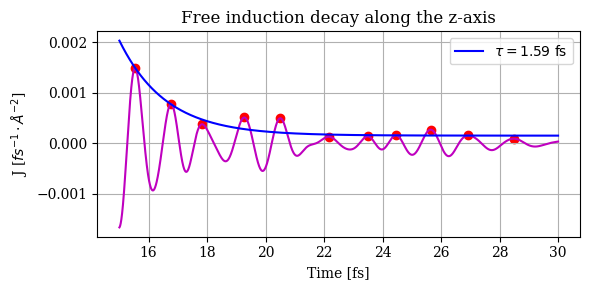

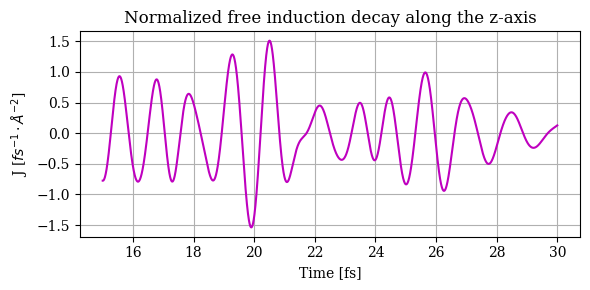

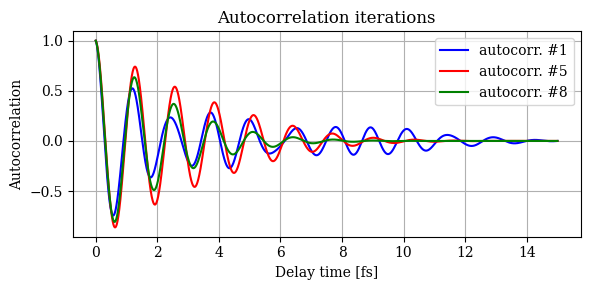

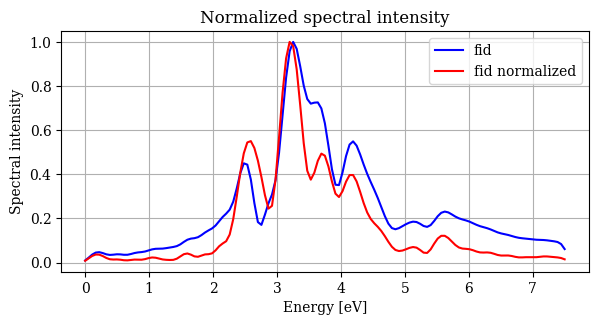

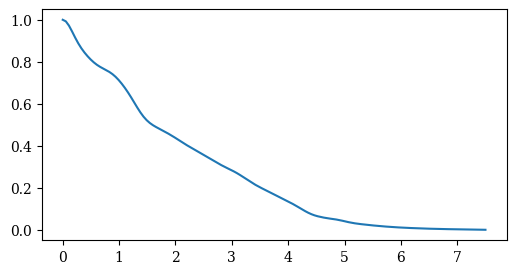

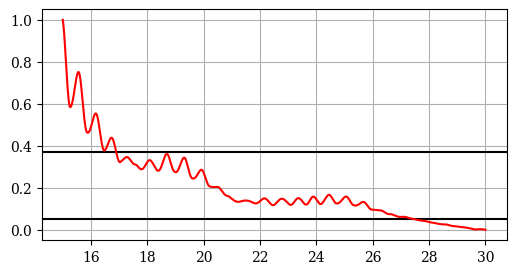

For c333_s0.075_r18_k16_a1_i804_t9_p4d10_1d12 z-axis fid plots are completed
Mandel's time fot fid normalized signal 2.7546419853770834
For c333_s0.075_r18_k16_a1_i804_t9_p4d10_1d12 z-axis fid data saving in csv format is completed
Mandel's coherence time: 1.4412090402610347
1.823274661908556
1.886607902118588
1.9186479891337693
2.158560375082284
2.5575712559458226
2.783304779867518
2.8116526397655264
2.718116253926437
2.5426647675179463
2.3315394394633735
Spectrum autocorrelation time: 
3.0328229770666666
1.5379999999999985
9.208


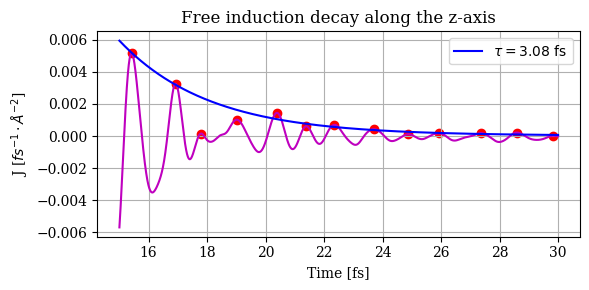

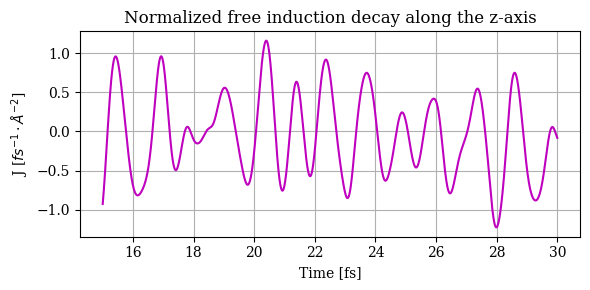

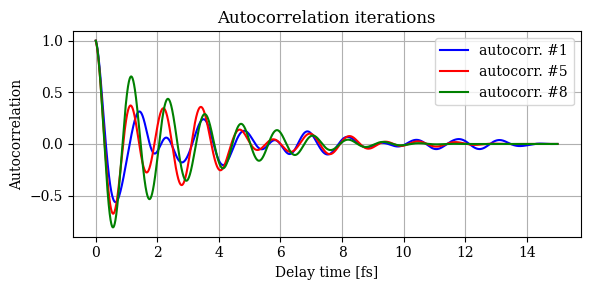

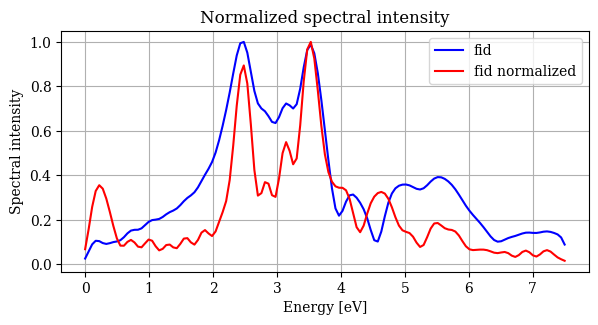

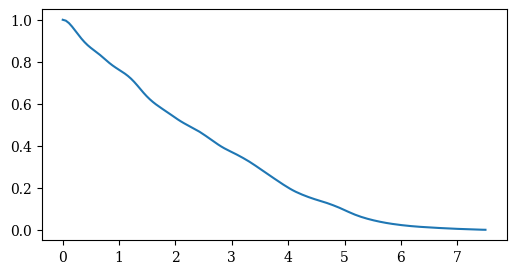

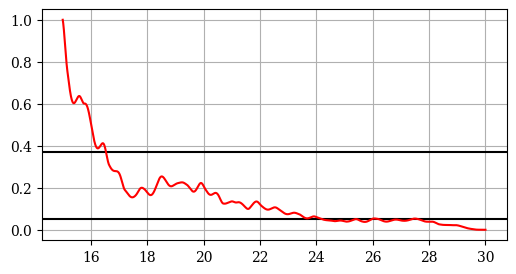

In [68]:
tau_fid_z_arr = []

auto_corr_mandels_coherence=[]

mandels_coherence_arr=[]

autocorr_fid_1_e_arr=[]
autocorr_fid_3_e_arr=[]

normalized_fid_mandels_coherence=[]

eV_autocorrelation_fid=[]

j=0
for folder in sorted_folders:

    j=j+1
    
    t_probe, t_pump = get_pulse_durations(folder)
    
    m0_cut_1 = int(500*t_probe) # duration of probe pulse for exp fit after it
    m0_cut_3 = int(m0_cut_1/2)  # start of integration for Δk analysis. half of probe pulse duration
    
    m0_cut_2 = m0_cut_3+500 # adjustable. start for drude x-fit (needs to be adjusted in accordance to z_pump energy)
    
    m0_cut_4 = int(500*(t_probe+t_pump)/2) # pump exp fit, at the end of the pump pulse
    
    # Загрузка данных, пропуская строки с комментариями (начинаются с #)
    data_both = pd.read_csv(
        folder + '/both_pulses_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    data_pump = pd.read_csv(
        folder + '/pump_pulse_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    data_probe = pd.read_csv(
        folder + '/probe_pulse_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    
    # Назначим читаемые имена колонкам
    data_both.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']
    
    data_pump.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']
    
    data_probe.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']
    
    
    t = data_both['time_fs']
    
    
    Jm_both_z  =  data_both['Jm_z']
    Jm_pump_z  =  data_pump['Jm_z']
    Jm_probe_z =  data_probe['Jm_z']
    
    Jm_both_x  =  data_both['Jm_x']
    Jm_pump_x  =  data_pump['Jm_x']
    Jm_probe_x =  data_probe['Jm_x']
    
    Jm_both_y  =  data_both['Jm_y']
    Jm_pump_y  =  data_pump['Jm_y']
    Jm_probe_y =  data_probe['Jm_y']
    
    
    El_f_pump_z = data_both['E_ext_z']
    El_f_probe_x = data_both['E_ext_x']
    
    
    
    t_array_cut = np.array(t[m0_cut_4:])[::50]
    j_exp = np.array(Jm_pump_z[m0_cut_4:])[::50]
    # (dummy_t, j0, j_final, tau)
    p0 = [0.02, 0, 6.65]   # начальные приближения (n, tau)
    popt, pcov = curve_fit(drude_exp_fit_v2_pump, t_array_cut, j_exp, p0=p0)
    j0, j_final, tau_pump= popt
    j_fit = drude_exp_fit_v2_pump(0, j0, j_final, tau_pump)
    
    # ratio = j_final/max(delta_Jm_x)
    
    # # Разностный ток по x
    # plt.plot(t, Jm_pump_z, color='m')
    # if tau_pump<30:
    #     plt.plot(t_array_cut, j_fit, '--', label=rf"$\tau = {tau_pump:.2f}\ \mathrm{{fs}}$", color='r')
    # else: plt.plot(t_array_cut, j_fit, '--', color='r')
    # plt.xlabel('Time [fs]')
    # plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
    # plt.title('Matter current density along z, only pump')
    # plt.legend()
    # plt.grid(True)
    # plt.tight_layout()
    
    
    
    
    interp_f = interp1d(t_array_cut, j_fit, kind="linear", fill_value="extrapolate")
    # t_array_cut_full = np.linspace(t_array_cut[0], 30, 15000-m0_cut_4)    # сетка на [t1, t2]
    j_fit_full = interp_f(t[m0_cut_4:])  
    
    
    t_z_exp_fit = t[m0_cut_4:]
    fid_z = Jm_pump_z[m0_cut_4:]-j_fit_full
    t_peaks_vals, fid_peak_vals = find_halfcycle_maxima(np.array(t_z_exp_fit), np.array(fid_z))
    
    
    # fit peak points
    t_fit_vals = t_peaks_vals
    y_fit_vals = fid_peak_vals
    
    exclude_array=[]
    exclude_array = [2, 3, 4]
    t_fit_vals = np.delete(t_fit_vals, exclude_array)
    y_fit_vals = np.delete(y_fit_vals, exclude_array)
    
    params, cov = fit_exp_gauss(t_fit_vals, y_fit_vals)
    
    A, tau_exp_z, t0, sigma, C = params

    tau_fid_z_arr.append(tau_exp_z)
    
    # print("Fit parameters:")
    # print(f"A = {A}")
    # print(f"tau = {tau_exp_z}")
    # print(f"t0 = {t0}")
    # print(f"sigma = {sigma}")
    # print(f"C = {C}")
    
    # построение
    t_fit = t_z_exp_fit
    y_fit = exp_gauss(t_fit, *params)

    plt.figure(figsize=(6, 3))
    
    plt.plot(t[m0_cut_4:], Jm_pump_z[m0_cut_4:]-j_fit_full, color='m')
    plt.scatter(t_peaks_vals, fid_peak_vals, color='r')
    plt.plot(t_fit, y_fit, color='b', label= rf"$\tau = {tau_exp_z:.2f}\ \mathrm{{fs}}$")
    plt.grid()
    plt.legend()
    plt.xlabel('Time [fs]')
    plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
    plt.title('Free induction decay along the z-axis')
    plt.tight_layout()

    
    plt.savefig("all_data/fid/z/ims/png/" + str(j)+ '_fid_z_' + folder + ".png", dpi=200)
    plt.savefig("all_data/fid/z/ims/pdf/" + str(j)+ '_fid_z_' + folder + ".pdf", bbox_inches="tight")

    print("For " + folder + " z-axis fid plots are completed")



    plt.figure(figsize=(6, 3))
    plt.plot(t[m0_cut_4:], (Jm_pump_z[m0_cut_4:]-j_fit_full)/(y_fit+max(fid_peak_vals[-4:])-C), color='m')
    plt.grid()
    plt.xlabel('Time [fs]')
    plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
    plt.title('Normalized free induction decay along the z-axis')
    plt.tight_layout()

    plt.savefig("all_data/fid/z/ims/png/" + str(j)+ '_normalized_fid_z_' + folder + ".png", dpi=200)
    plt.savefig("all_data/fid/z/ims/pdf/" + str(j)+ '_normalized_fid_z_' + folder + ".pdf", bbox_inches="tight")
    

    normalized_fid_signal=(Jm_pump_z[m0_cut_4:]-j_fit_full)/(y_fit+max(fid_peak_vals[-4:])-C)


    print("Mandel's time fot fid normalized signal", coherence_time(normalized_fid_signal, 0.002))
    normalized_fid_mandels_coherence.append(coherence_time(normalized_fid_signal, 0.002))
    


    fid_signal = Jm_pump_z[m0_cut_4:]-j_fit_full
    
    each_num=5
    
    fid_data_array=np.array([  t[m0_cut_4:][::each_num], fid_signal[::each_num], y_fit[::each_num]  ])
    
    columns = ["time",  "fid_signal", "fid_exp_fit"]
    df = pd.DataFrame(fid_data_array.T, columns=columns)
    
    
    df.to_csv("all_data/fid/z/data/" + str(j)+ "_fid_z_" + folder + ".csv", index=False)
    
    with open("all_data/fid/z/data/" + str(j)+ "_fid_z_" + folder + ".csv", "w") as f:
        f.write("# Units: Time [fs], Current Jm [1/fs*Angstrom^2]")
        df.to_csv(f, index=False)
    
    print("For " + folder + " z-axis fid data saving in csv format is completed")

    print("Mandel's coherence time:", coherence_time(np.array(fid_signal), 0.002))
    mandels_coherence_arr.append(coherence_time(np.array(fid_signal), 0.002))



    plt.figure(figsize=(6, 3))

    plt.grid()
    plt.xlabel('Delay time [fs]')
    plt.ylabel('Autocorrelation')
    plt.title('Autocorrelation iterations')
    

    
    auto_corr = np.correlate(fid_signal, fid_signal, 'full')   # линейная корреляция (вне отрезка = 0)
    auto_corr = auto_corr[len(fid_signal)-1:]                 # лаги >= 0
    auto_corr = auto_corr / auto_corr[0]  

    colors=['b', 'olive', 'r', 'g', 'm', 'orange', 'gold', 'purple', 'slateblue', 'navy', 'darkred']
    
    plt.plot(t[m0_cut_4:]-t[m0_cut_4], auto_corr, label="autocorr. #1", color=colors[0])

    num_auto_corr_iters=10
    auto_corr_coh_vals=[]
    for i in range(num_auto_corr_iters):
    
        new_auto_corr = np.correlate(auto_corr, auto_corr, 'full')   # линейная корреляция (вне отрезка = 0)
        new_auto_corr = new_auto_corr[len(auto_corr)-1:]                 # лаги >= 0
        new_auto_corr = new_auto_corr / new_auto_corr[0]
        
        auto_corr=new_auto_corr

        print(coherence_time(auto_corr, 0.002))
        
        auto_corr_coh_vals.append(coherence_time(auto_corr, 0.002))
    
        if i!=0 and i%(3)==0 and i//3 < 3:
            plt.plot(t[m0_cut_4:]-t[m0_cut_4], new_auto_corr, label= rf"autocorr. #{int(i+2)}", color=colors[int(i//3+1)])

    plt.tight_layout()
    plt.legend()

    plt.savefig("all_data/fid/z/ims/png/" + str(j)+ '_autocorrelation_iters_fid_z_' + folder + ".png", dpi=200)
    plt.savefig("all_data/fid/z/ims/pdf/" + str(j)+ '_autocorrelation_iters_fid_z_' + folder + ".pdf", bbox_inches="tight")
    
    auto_corr_mandels_coherence.append(max(auto_corr_coh_vals))
    # auto_corr_mandels_coherence.append(coherence_time(auto_corr, 0.002))


    
    plt.figure(figsize=(6, 3))
    plt.grid()
    plt.title('Normalized spectral intensity')

    plt.xlabel("Energy [eV]")
    plt.ylabel("Spectral intensity")
    
    # second variable is convolve parameter val in eV
    F_ens, F_fid = fourier_plot(fid_signal, 1.2)
    plt.plot(F_ens, F_fid, color='b', label='fid')
    # plt.ylim(0, 1.1)
    # plt.xlim(1, E_eV[-1]/120)  
    F_ens, F_fid_normalized = fourier_plot(normalized_fid_signal, 1.2)
    plt.plot(F_ens, F_fid_normalized, color='r', label='fid normalized')
    
    plt.legend()

    plt.tight_layout()


    plt.savefig("all_data/fid/z/ims/png/" + str(j)+ '_spectral_intensity_fid_z_' + folder + ".png", dpi=200)
    plt.savefig("all_data/fid/z/ims/pdf/" + str(j)+ '_spectral_intensity_fid_z_' + folder + ".pdf", bbox_inches="tight")


    plt.figure(figsize=(6, 3))

    auto_corr = np.correlate(F_fid, F_fid, 'full')   # линейная корреляция (вне отрезка = 0)
    auto_corr = auto_corr[len(F_fid)-1:]                 # лаги >= 0
    auto_corr = auto_corr / auto_corr[0]  

    i_0 = np.where(auto_corr < 0.369)[0][0]
    print("Spectrum autocorrelation time: ")
    print(np.array(F_ens)[int(i_0)]-np.array(F_ens)[0])
    plt.plot(F_ens, auto_corr)

    eV_autocorrelation_fid.append(np.array(F_ens)[int(i_0)]-np.array(F_ens)[0])


    

    plt.figure(figsize=(6, 3))
    auto_corr = np.correlate(abs(fid_signal), abs(fid_signal), 'full')   # линейная корреляция (вне отрезка = 0)
    auto_corr = auto_corr[len(fid_signal)-1:]                 # лаги >= 0
    auto_corr = auto_corr / auto_corr[0]  

    
    plt.axhline(y=0.369, color='black')
    plt.axhline(y=0.05, color='black')
    plt.plot(t[m0_cut_4:], auto_corr, color='r')
    plt.grid()

    i_1 = np.where(auto_corr < 0.369)[0][0]
    print(np.array(t[m0_cut_4:])[int(i_1)]-np.array(t[m0_cut_4:])[0])
    
    i_2 = np.where(auto_corr < 0.05)[0][0]
    print(np.array(t[m0_cut_4:])[int(i_2)]-np.array(t[m0_cut_4:])[0])

    autocorr_fid_1_e_arr.append(np.array(t[m0_cut_4:])[int(i_1)]-np.array(t[m0_cut_4:])[0])
    autocorr_fid_3_e_arr.append(  (np.array(t[m0_cut_4:])[int(i_2)]-np.array(t[m0_cut_4:])[0])/3  )


    plt.show()

    


    

print(" ")

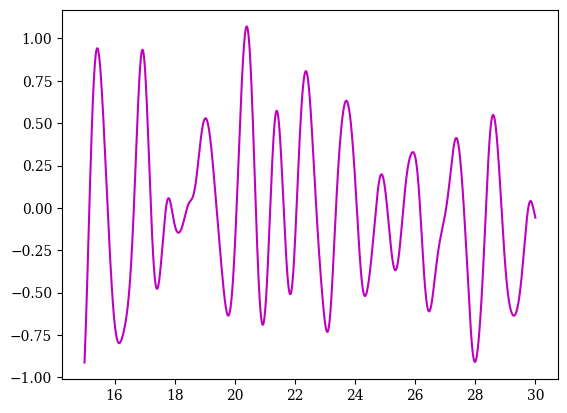

In [441]:
plt.plot(t[m0_cut_4:], (Jm_pump_z[m0_cut_4:]-j_fit_full)/(y_fit+0.0003), color='m')
# plt.plot(t_fit, y_fit)

In [498]:
# plt.plot(t[m0_cut_4:], fid_signal)
normalized_fid_mandels_coherence

[np.float64(2.687008153647802),
 np.float64(4.265841861843153),
 np.float64(2.010399838054839),
 np.float64(3.7685283704010084),
 np.float64(2.7546419853770834)]

In [497]:
1/np.array(normalized_fid_mandels_coherence)

array([0.37216113, 0.23442032, 0.49741349, 0.26535557, 0.36302358])

In [506]:
1/np.array(new_taus) + 1/np.array(normalized_fid_mandels_coherence)
# очень неплохо совпадает что говорит о валидности разделения!
# 1/np.array(new_taus) (чистые экспоненты) + 1/np.array(normalized_fid_mandels_coherence) (чистое затухание от экспоненты) =
# = 1/np.array(mandels_coherence_arr) (общее время затухания)

array([0.62293082, 0.45263444, 0.6623475 , 0.62012661, 0.61438209])

In [519]:
1/np.array(tau_fid_z_arr) + 1/np.array(normalized_fid_mandels_coherence)
# плохо совпадает. жесть конечно бля странно. ведь именно эту экспоненту я брал чтобы нормировать ... но она кривая конечно ...

array([0.57377005, 0.59392991, 0.679316  , 0.89298171, 0.68821691])

In [520]:
1/np.array(mandels_coherence_arr)

array([0.60550987, 0.45910861, 0.683057  , 0.43667643, 0.69386187])

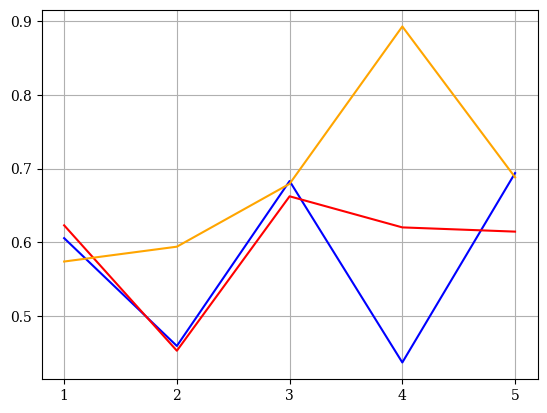

In [522]:
# СПЕКУЛЯТИВНО

folder_nums = np.linspace(1, len(new_taus), len(new_taus))
plt.xticks(folder_nums)
plt.plot(folder_nums, 1/np.array(mandels_coherence_arr), color='b')
plt.plot(folder_nums, 1/np.array(new_taus) + 1/np.array(normalized_fid_mandels_coherence), color='r')
plt.plot(folder_nums, 1/np.array(tau_fid_z_arr) + 1/np.array(normalized_fid_mandels_coherence), color='orange')
plt.grid()

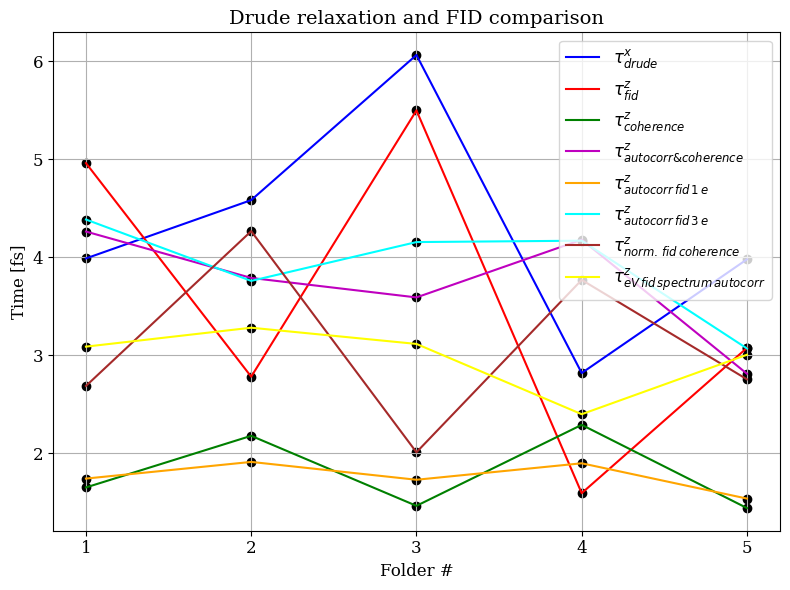

In [536]:
plt.figure(figsize=(8, 6))

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.legend(fontsize=12)

plt.title("Drude relaxation and FID comparison", fontsize=14)
folder_nums = np.linspace(1, len(new_taus), len(new_taus))
plt.plot(folder_nums, new_taus, color='b', label=r'$\tau_{drude}^x$')
plt.plot(folder_nums, tau_fid_z_arr, color='r', label=r'$\tau_{fid}^z$')

plt.plot(folder_nums, np.array(mandels_coherence_arr), color='g', label=r'$\tau_{coherence}^z$')
plt.scatter(folder_nums, np.array(mandels_coherence_arr), color='black')


plt.plot(folder_nums, np.array(auto_corr_mandels_coherence), color='m', label=r'$\tau_{autocorr&coherence}^z$')
plt.scatter(folder_nums, np.array(auto_corr_mandels_coherence), color='black')




plt.plot(folder_nums, np.array(autocorr_fid_1_e_arr), color='orange', label=r'$\tau_{autocorr \, fid \,1 \,e}^z$')
plt.scatter(folder_nums, np.array(autocorr_fid_1_e_arr), color='black')


plt.plot(folder_nums, np.array(autocorr_fid_3_e_arr), color='aqua', label=r'$\tau_{autocorr \, fid \,3 \,e}^z$')
plt.scatter(folder_nums, np.array(autocorr_fid_3_e_arr), color='black')


plt.plot(folder_nums, np.array(normalized_fid_mandels_coherence), color='brown', label=r'$\tau_{norm. \, fid \, coherence}^z$')
plt.scatter(folder_nums, np.array(normalized_fid_mandels_coherence), color='black')



plt.plot(folder_nums, np.array(eV_autocorrelation_fid), color='yellow', label=r'$\tau_{eV \, fid \, spectrum \, autocorr}^z$')
plt.scatter(folder_nums, np.array(eV_autocorrelation_fid), color='black')


plt.scatter(folder_nums, new_taus, color='black')
plt.scatter(folder_nums, tau_fid_z_arr, color='black')
plt.ylabel("Time [fs]", fontsize=12)
plt.xlabel("Folder #", fontsize=12)
plt.xticks(folder_nums)
plt.legend(fontsize=12)
plt.grid()
plt.tight_layout()

plt.savefig("all_data/fid/" + 'tau_comparison.png', dpi=200)
plt.savefig("all_data/fid/" + 'tau_comparison.pdf', bbox_inches="tight")

In [409]:
autocorr_fid_2_e_arr

[np.float64(3.5119999999999996),
 np.float64(3.006999999999999),
 np.float64(3.4769999999999994),
 np.float64(3.063999999999999),
 np.float64(2.8129999999999997)]

In [411]:
1/np.array(autocorr_fid_2_e_arr)

array([0.28473804, 0.33255737, 0.28760426, 0.32637076, 0.35549236])

In [417]:
1/np.array(autocorr_fid_1_e_arr)

array([0.57405281, 0.52301255, 0.57803468, 0.52687039, 0.65019506])

In [416]:
1/np.array(new_taus)

array([0.25076969, 0.21821413, 0.16493401, 0.35477104, 0.25135851])

theory: 2*sigma = 2 fs
wtf 2.5066282746323885


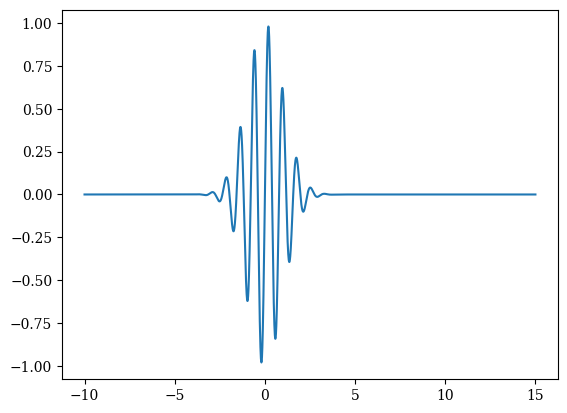

In [628]:
sigma = 1  # fs
dt = 0.001
t = np.arange(-10, 15, dt)
y = np.sin(8*t)*np.exp(-((t-0)**2) / (2*sigma**2))

plt.plot(t, y)

print("theory: 2*sigma =", 2*sigma, "fs")
print("wtf", coherence_time(y, dt))

0.14899999999991742


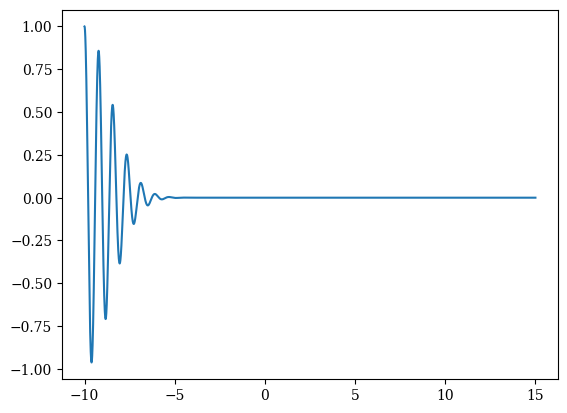

In [629]:
auto_corr = np.correlate(y, y, 'full')   # линейная корреляция (вне отрезка = 0)
auto_corr = auto_corr[len(y)-1:]                 # лаги >= 0
auto_corr = auto_corr / auto_corr[0]  

plt.plot(t, auto_corr)
# plt.plot(t, y)

i_1_e = np.where(auto_corr < 0.369)[0][0]

print(t[i_1_e]-t[0])

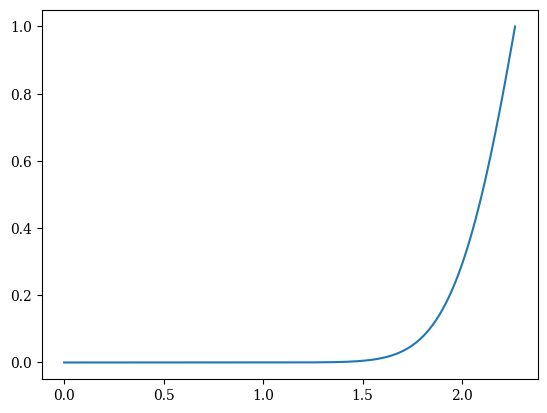

In [630]:
ens_eV, Fw_y = fourier_plot(y, dt)

plt.plot(ens_eV, Fw_y)

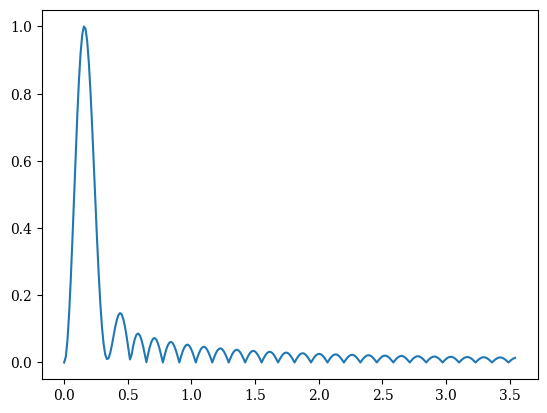

In [575]:
ens_eV, Fw_y = fourier_plot(y, 0.0001)

plt.plot(ens_eV, Fw_y)

In [258]:
E_eV[1]

np.float64(0.2757111797333333)

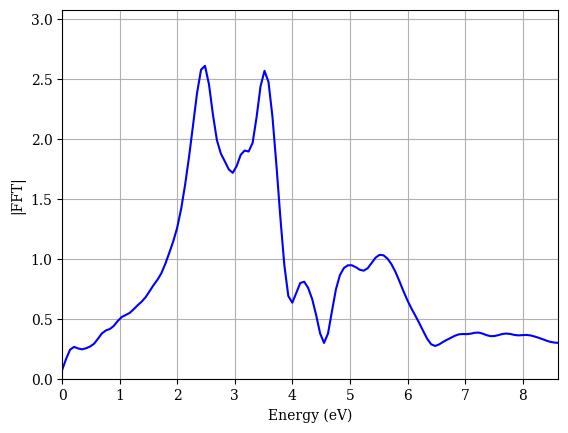

5.902832145699848 eV width
0.06892779493333333
7.513129647733333 max eV


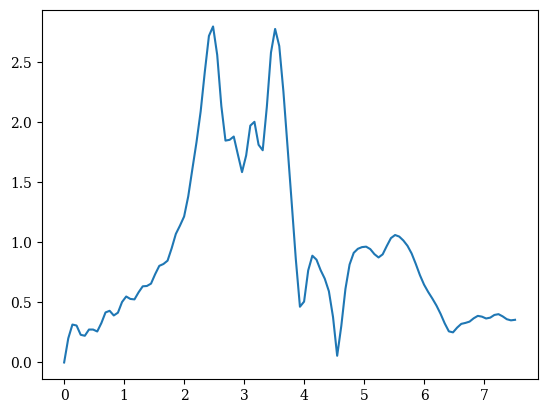

In [524]:
N = len(fid_signal)

# убираем среднее (рекомендовано)
x = np.array(fid_signal)-np.mean(fid_signal)

# FFT
M=4
xpad = np.pad(x, (0, (M-1)*len(x)))
X = np.fft.rfft(xpad)
freq = np.fft.rfftfreq(M*N, d=0.002)   # частота в 1/fs

# ---- единственная физическая константа ----
h_eV_fs = 4.135667696                # eV·fs
E_eV = h_eV_fs * freq

# амплитуда
A = np.abs(X)

# график
# plt.plot(E_eV, A, color='b')

plt.plot(E_eV, gaussian_convolve(A, 1.2), color='b')

plt.xlabel("Energy (eV)")
plt.ylabel("|FFT|")
plt.ylim(0, max(A)*1.1)
plt.xlim(0, E_eV[-1]/120)
plt.grid()
plt.show()

print(coherence_time(A[:int(110*M/4)], E_eV[1]-E_eV[0]), "eV width")
print(E_eV[1]-E_eV[0])
print(E_eV[:int(110*M/4)][-1], "max eV")

plt.plot(E_eV[:int(110*M/4)], A[:int(110*M/4)])

In [420]:
# E_eV[:int(110*M/4)]

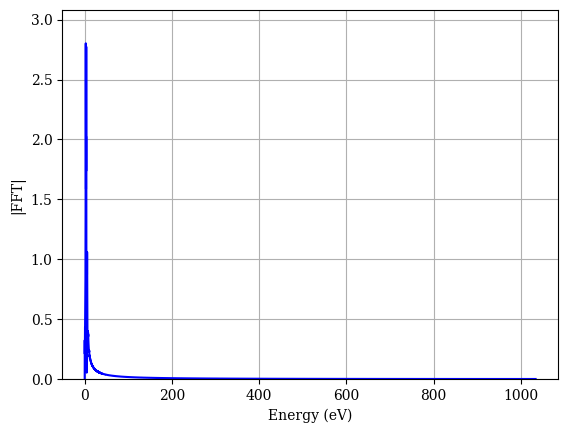

5.9232176871964395 eV width

7.554486324693333 max eV


In [529]:
N = len(fid_signal)

# убираем среднее (рекомендовано)
x = np.array(fid_signal)-np.mean(fid_signal)

# FFT
M=10
xpad = np.pad(x, (0, (M-1)*len(x)))
X = np.fft.rfft(xpad)
freq = np.fft.rfftfreq(M*N, d=0.002)   # частота в 1/fs

# ---- единственная физическая константа ----
h_eV_fs = 4.135667696                # eV·fs
E_eV = h_eV_fs * freq

# амплитуда
A = np.abs(X)

# график
plt.plot(E_eV, A, color='b')
plt.xlabel("Energy (eV)")
plt.ylabel("|FFT|")
plt.ylim(0, max(A)*1.1)
# plt.xlim(0, E_eV[-1]/120)
plt.grid()
plt.show()

print(coherence_time(A[:int(110*M/4)], E_eV[1]-E_eV[0]), "eV width")
print()
print(E_eV[:int(110*M/4)][-1], "max eV")

In [530]:
F_signal = A[:int(110*M/4)]
F_signal = A

auto_corr = np.correlate(F_signal, F_signal, 'full')   # линейная корреляция (вне отрезка = 0)
auto_corr = auto_corr[len(F_signal)-1:]                 # лаги >= 0
auto_corr = auto_corr / auto_corr[0]  

i_0 = np.where(auto_corr < 0.369)[0][0]
print(np.array(E_eV[:int(110*M/4)])[int(i_0)]-np.array(E_eV[:int(110*M/4)])[0])

3.5291031005866667


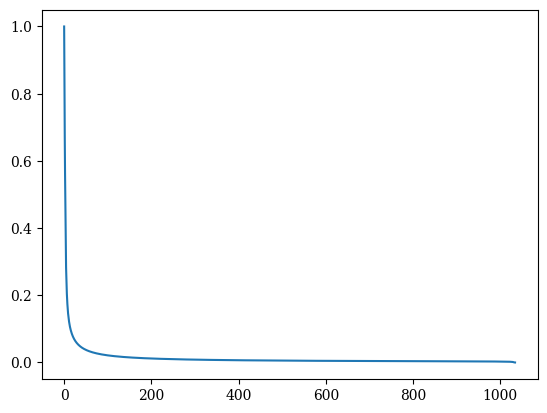

In [531]:
plt.plot(E_eV[:int(110*M/4)], auto_corr)

1.5379999999999985
5.6259999999999994


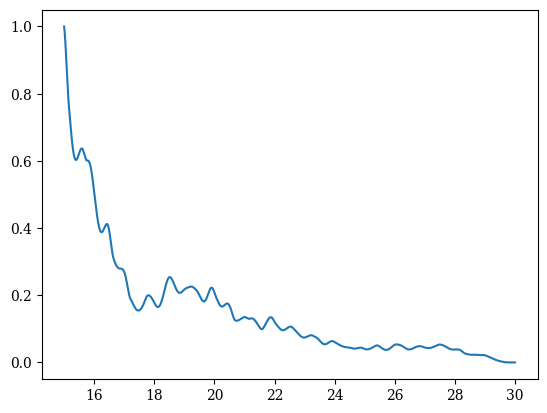

In [392]:
auto_corr = np.correlate(abs(fid_signal), abs(fid_signal), 'full')   # линейная корреляция (вне отрезка = 0)
auto_corr = auto_corr[len(fid_signal)-1:]                 # лаги >= 0
auto_corr = auto_corr / auto_corr[0]  

plt.plot(t[m0_cut_4:], auto_corr)

i_1 = np.where(auto_corr < 0.369)[0][0]
print(np.array(t[m0_cut_4:])[int(i_1)]-np.array(t[m0_cut_4:])[0])

i_2 = np.where(auto_corr < 0.136)[0][0]
print(np.array(t[m0_cut_4:])[int(i_2)]-np.array(t[m0_cut_4:])[0])

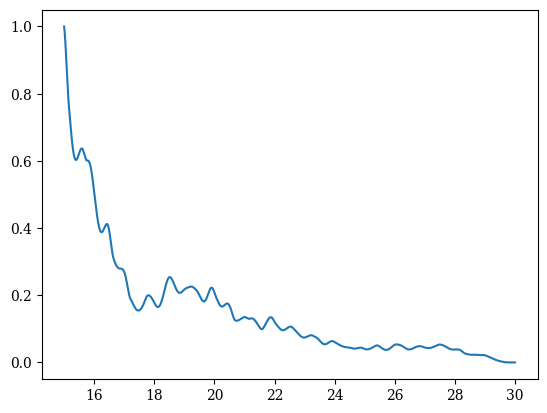

In [382]:
# plt.plot(t[m0_cut_4:], abs(fid_signal))
plt.plot(t[m0_cut_4:], auto_corr)

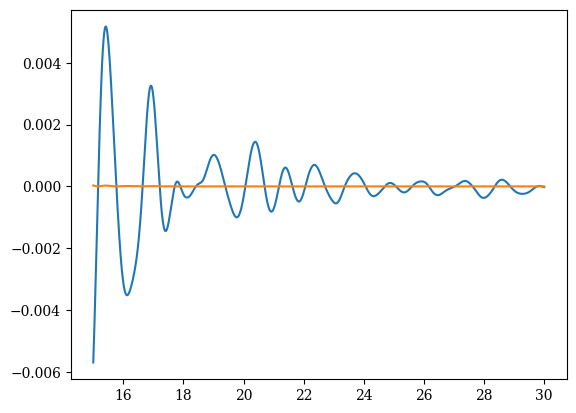

In [179]:
plt.plot(t[m0_cut_4:], fid_signal)
plt.plot(t[m0_cut_4:], fid_signal**2)

In [166]:
fid_signal

7500    -0.005699
7501    -0.005641
7502    -0.005583
7503    -0.005524
7504    -0.005464
           ...   
14995   -0.000019
14996   -0.000020
14997   -0.000020
14998   -0.000021
14999   -0.000021
Name: Jm_z, Length: 7500, dtype: float64

1.823274661908556
1.886607902118588
1.9186479891337693
2.158560375082284
2.5575712559458226
2.783304779867518
2.8116526397655264
2.718116253926437
2.5426647675179463
2.3315394394633735
2.1226851541680976
1.9345355117653722
1.7715713905162322
1.6320710769749027
1.512543466450158
1.4095150224868735
1.3200477188095627
1.241782665720174
1.1728484747480314
1.1117542679838264


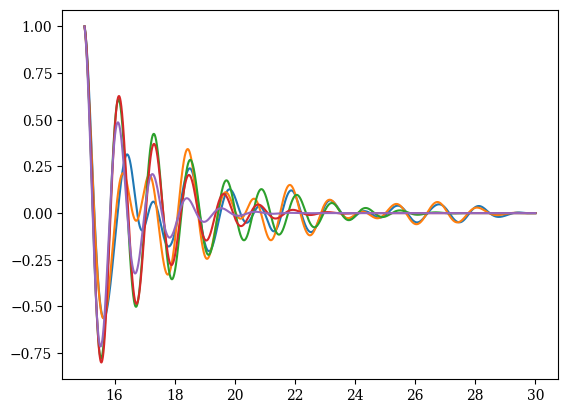

In [239]:
auto_corr = np.correlate(fid_signal, fid_signal, 'full')   # линейная корреляция (вне отрезка = 0)
auto_corr = auto_corr[len(fid_signal)-1:]                 # лаги >= 0
auto_corr = auto_corr / auto_corr[0]  

plt.plot(t[m0_cut_4:], auto_corr)

for i in range(20):

    new_auto_corr = np.correlate(auto_corr, auto_corr, 'full')   # линейная корреляция (вне отрезка = 0)
    new_auto_corr = new_auto_corr[len(auto_corr)-1:]                 # лаги >= 0
    new_auto_corr = new_auto_corr / new_auto_corr[0]
    
    auto_corr=new_auto_corr

    print(coherence_time(auto_corr, 0.002))

    if i%5==0:
        plt.plot(t[m0_cut_4:], new_auto_corr)



In [195]:
10%3

1

In [ ]:
         
auto_corr = np.correlate(signal, signal, 'full')   # линейная корреляция (вне отрезка = 0)
auto_corr = auto_corr[len(x)-1:]                 # лаги >= 0
auto_corr = auto_corr / auto_corr[0]                     # нормировка: R(0)=1

dt = t[1] - t[0]
tau = np.arange(len(auto_corr)) * dt

plt.plot(tau, auto_corr)
plt.xlabel(r'$\tau$')
plt.ylabel(r'$R(\tau)$')
plt.show()

## drude

In [95]:
def effecive_mass_model(alpha, a, b, c):
    return 1/(a**2 * alpha**4 + 0*alpha**4 + c)

In [96]:
delta_start_drude_fit = 300

def generalized_drude_current_v8_tau_j_final_free_mass_adjustment(dummy_t, j0, a, b, c, tau, j_final, idx):

    
    data_both = pd.read_csv(
        folder + '/both_pulses_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    
    data_both.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']
    
    t = data_both['time_fs']
    El_f_probe_x = data_both['E_ext_x']
    
    
    step_dt = 0.002
    


    t_probe, t_pump = get_pulse_durations(folder)

    m0_cut_1 = int(500*t_probe) # duration of probe pulse for exp fit after it
    m0_cut_3 = int(m0_cut_1/2)  # start of integration for Δk analysis. half of probe pulse duration
    
    m0_cut_2 = m0_cut_3+delta_start_drude_fit # adjustable. start for drude x-fit (needs to be adjusted in accordance to z_pump energy)
    
    m0_cut_4 = int(500*(t_probe+t_pump)/2) # pump exp fit, at the end of the pump pulse

    
    
    dt = np.diff(t, prepend=t[0])
    
    
    alpha_E_t = np.cumsum(-2.64*El_f_probe_x[m0_cut_3:]*dt[m0_cut_3:])
    fit_alpha_E_t = alpha_E_t[m0_cut_2-m0_cut_3:]
    
    alpha_fit = np.array(effecive_mass_model(fit_alpha_E_t, a, b, c))
    
    
    
    # --- Задаём поле в дискретных точках ---
    t_array = np.array(t[m0_cut_2:])         # сетка времени
    E_array = -np.array(El_f_probe_x[m0_cut_2:]) 
    
        
    # --- Решение через явный шаг Эйлера ---
    
    j_euler = np.zeros_like(t_array)
    j_euler[0] = j0
    
    for k in range(len(t_array)-1):
        j_euler[k+1] = j_euler[k] + step_dt * (-(j_euler[k]-j_final)/tau + alpha_fit[k] * E_array[k])

    
    return j_euler[::1]

10.074970533522496 4715.1084441906205 20.571193829449296
For c333_s0.050_r18_k16_a1_i804_t9_p1.5d11_1d12 drude fit plots are completed
For c333_s0.050_r18_k16_a1_i804_t9_p1.5d11_1d12 drude fit current data saving in csv format is completed
9.739275635779347 5029.7153080325825 10.636159029509784
For c333_s0.00_r18_k16_a1_i800_t9_p4d10_1d12_load_№1162_amorphous_0.976 drude fit plots are completed
For c333_s0.00_r18_k16_a1_i800_t9_p4d10_1d12_load_№1162_amorphous_0.976 drude fit current data saving in csv format is completed
16.858495431052063 -10259.987635359215 21.565536772039046
For c333_s0.050_r18_k16_a1_i804_t9_p4d10_1d12 drude fit plots are completed
For c333_s0.050_r18_k16_a1_i804_t9_p4d10_1d12 drude fit current data saving in csv format is completed
19.99999999824858 9009.549499164546 255.34709932682983
For c333_s0.050_r18_k16_a1_i804_t9_p4d10_2d11 drude fit plots are completed
For c333_s0.050_r18_k16_a1_i804_t9_p4d10_2d11 drude fit current data saving in csv format is completed
10

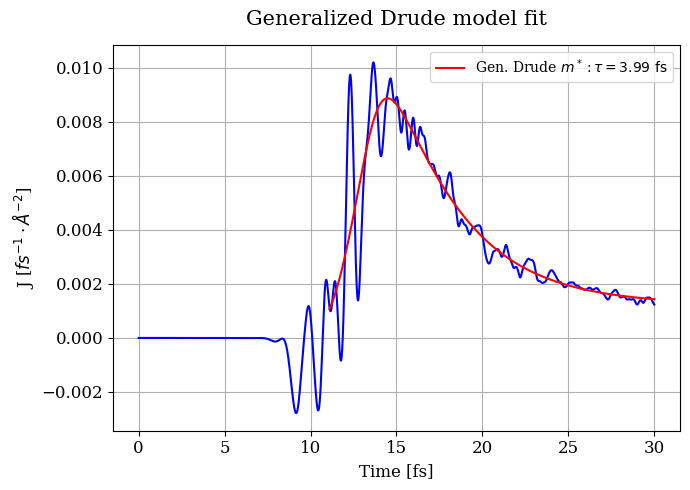

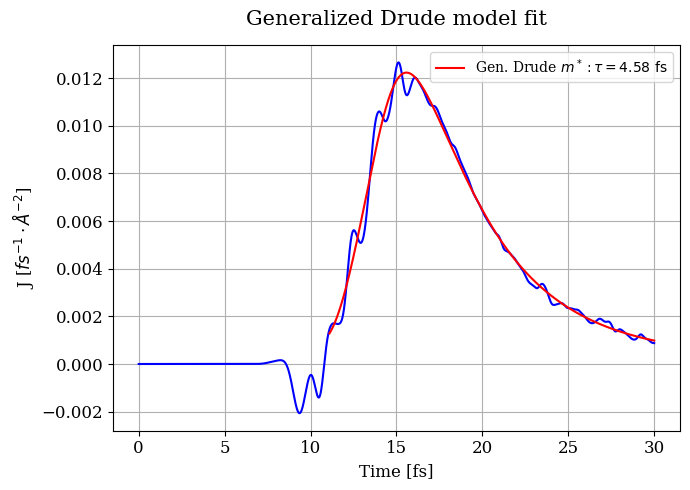

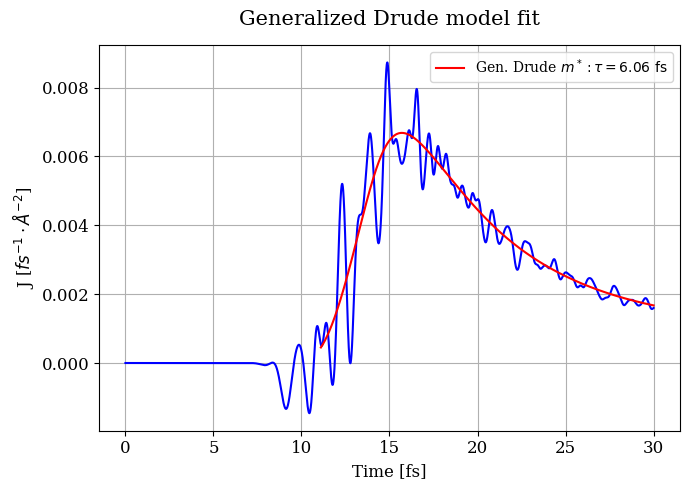

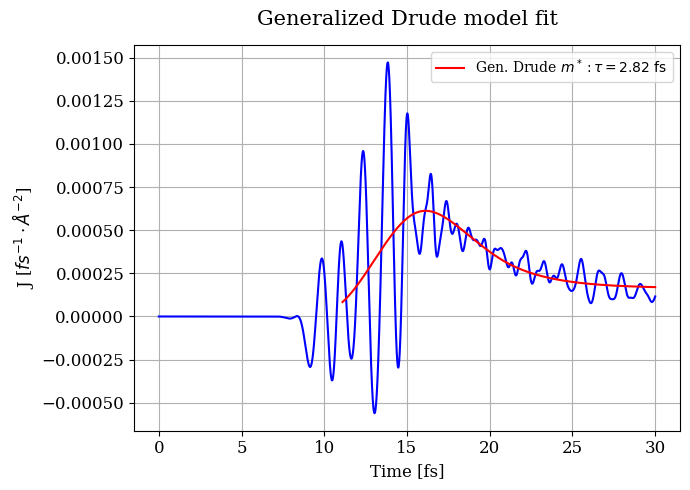

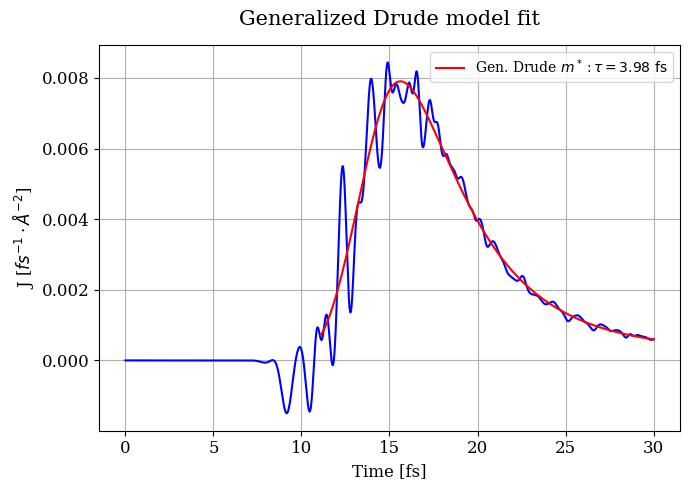

In [141]:
new_taus = []
new_j_finals = []
arr_abc = []

alphas_start = []
alphas_final = []

    
folder = sorted_folders[0]

j=0
num_folder=0
for folder in sorted_folders:

    j=j+1
    num_folder=num_folder+1
    
    t_probe, t_pump = get_pulse_durations(folder)
    
    m0_cut_1 = int(500*t_probe) # duration of probe pulse for exp fit after it
    m0_cut_3 = int(m0_cut_1/2)  # start of integration for Δk analysis. half of probe pulse duration
    
    m0_cut_2 = m0_cut_3+delta_start_drude_fit # adjustable. start for drude x-fit (needs to be adjusted in accordance to z_pump energy)
    
    m0_cut_4 = int(500*(t_probe+t_pump)/2) # pump exp fit, at the end of the pump pulse
    
    # Загрузка данных, пропуская строки с комментариями (начинаются с #)
    data_both = pd.read_csv(
        folder + '/both_pulses_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    
    data_probe = pd.read_csv(
        folder + '/probe_pulse_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    
    data_pump = pd.read_csv(
        folder + '/pump_pulse_rt.data',
        comment='#',
        delim_whitespace=True,
        header=None
    )
    
    
    # Назначим читаемые имена колонкам
    data_both.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']
    
    data_probe.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']
    
    data_pump.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
        'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
        'Jm_x', 'Jm_y', 'Jm_z']
    
    
    t = data_both['time_fs']
    
    
    Jm_both_z  =  data_both['Jm_z']
    
    Jm_both_x  =  data_both['Jm_x']
    Jm_pump_x  =  data_pump['Jm_x']
    Jm_probe_x =  data_probe['Jm_x']
    
    Jm_both_y  =  data_both['Jm_y']
    Jm_pump_y  =  data_pump['Jm_y']
    Jm_probe_y =  data_probe['Jm_y']
    
    
    El_f_pump_z = data_both['E_ext_z']
    El_f_probe_x = data_both['E_ext_x']


    dt = np.diff(t, prepend=t[0])
    
    arr = np.array(np.cumsum(-2.64*El_f_probe_x[m0_cut_3:m0_cut_1+1000]*dt[m0_cut_3:m0_cut_1+1000]))
    a_start = arr[m0_cut_2-m0_cut_3]
    a_fin = arr[-1]

    alphas_start.append(a_start)
    alphas_final.append(a_fin)
    
    
    # fixed_generalized_drude_current_v2 = partial(generalized_drude_current_v2, arr_j_finals=j_finals, arr_alphas=alphas, arr_taus=taus, idx=num_folder)
    
    
    fixed_generalized_drude_current_v8_tau_j_final_free_mass_adjustment = partial(generalized_drude_current_v8_tau_j_final_free_mass_adjustment, idx=num_folder)
    
    
    
    delta_Jm_x = Jm_both_x - Jm_probe_x - Jm_pump_x
    
    # t_array_cut = np.array(t[m0_cut_2:])[::50]
    # j_exp = np.array(delta_Jm_x[m0_cut_2:])[::50]
    # # (dummy_t, j0, fit_alpha, j_final)
    # p0 = [0.03, 0.2]   # начальные приближения (n, tau)
    # # print(len(t_array_cut), len(j_exp))
    # popt, pcov = curve_fit(fixed_generalized_drude_current_v2, t_array_cut, j_exp, p0=p0)
    # j0, fit_alpha = popt
    # j_fit = fixed_generalized_drude_current_v2(0, j0, fit_alpha)
    
    plt.figure(figsize=(7,5))
    # plt.title(' '.join(re.split('[/_]', folder)), fontsize=14, y=1.03)
    plt.title("Generalized Drude model fit", fontsize=15, y=1.03)
    plt.plot(t, delta_Jm_x, color='b')
    # plt.plot(t_array_cut, j_fit, '-', label=r'Gen. Drude $\tau$', color='r')
    plt.xlabel("Time [fs]", fontsize=12)
    plt.ylabel("J [$fs^{-1} \\cdot Å^{-2}$]", fontsize=12)

    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    plt.legend(fontsize=12)
    
    
    t_array_cut = np.array(t[m0_cut_2:])[::1]
    j_exp = np.array(delta_Jm_x[m0_cut_2:])[::1]
    # (dummy_t, j0, fit_alpha, j_final)
    p0 = [0.04, 2, 0, 5, 5, 0]   # начальные приближения (n, tau)
    # print(len(t_array_cut), len(j_exp))
    popt, pcov = curve_fit(fixed_generalized_drude_current_v8_tau_j_final_free_mass_adjustment, t_array_cut, j_exp, p0=p0, bounds = (
    [-np.inf, 0, -np.inf, -np.inf, 0, -np.inf],[ np.inf, 20, np.inf, np.inf, np.inf, np.inf]
    ))
    j0, a, b, c, fit_tau_val, fit_j_fin_val = popt
    j_fit = fixed_generalized_drude_current_v8_tau_j_final_free_mass_adjustment(0, j0, a, b, c, fit_tau_val, fit_j_fin_val)
    
    new_taus.append(fit_tau_val)
    new_j_finals.append(fit_j_fin_val)
    
    plt.plot(t_array_cut, j_fit, '-', label=rf'Gen. Drude $m^*: \tau = {fit_tau_val:.2f}\ \mathrm{{fs}}$', color='r')
    plt.legend()
    plt.grid()
    arr_abc.append((a, b, c))
    print(a, b, c)

    plt.tight_layout()

    plt.savefig("all_data/drude/ims/png/" + str(j)+ '_drude_fit_' + folder + ".png", dpi=200)
    plt.savefig("all_data/drude/ims/pdf/" + str(j)+ '_drude_fit_' + folder + ".pdf", bbox_inches="tight")

    print("For " + folder + " drude fit plots are completed")




    j_fit_extended = np.concatenate(([None]*m0_cut_2, j_fit))
    
    drude_current_arr=np.array([t, delta_Jm_x, j_fit_extended])

    columns = ["time",  "delta_Jm_x", "delta_Jm_x_drude_fit"]
    df = pd.DataFrame(drude_current_arr.T, columns=columns)
    
    
    df.to_csv("all_data/drude/data/current/" + str(j)+ "_drude_current_" + folder + ".csv", index=False)
    
    with open("all_data/drude/data/current/" + str(j)+ "_drude_current_" + folder + ".csv", "w") as f:
        f.write(r"# Units: Time [fs], Current Jm [1/fs*Angstrom^2]" + "\n")
        df.to_csv(f, index=False)
    
    print("For " + folder + " drude fit current data saving in csv format is completed")

    


print(" ")

In [98]:
from matplotlib.colors import to_hex

def blue_red_gradient(n):
    """
    Возвращает список из n цветов (hex),
    создающих линейный градиент от синего к красному.
    """
    colors = []
    
    for i in range(n):
        t = i / (n - 1)  # параметр от 0 до 1
        
        r = t            # красный растёт
        g = 0            # зелёный фиксирован
        b = 1 - t        # синий убывает
        
        colors.append(to_hex((r, g, b)))
    
    return colors

Effective mass plots are completed
 


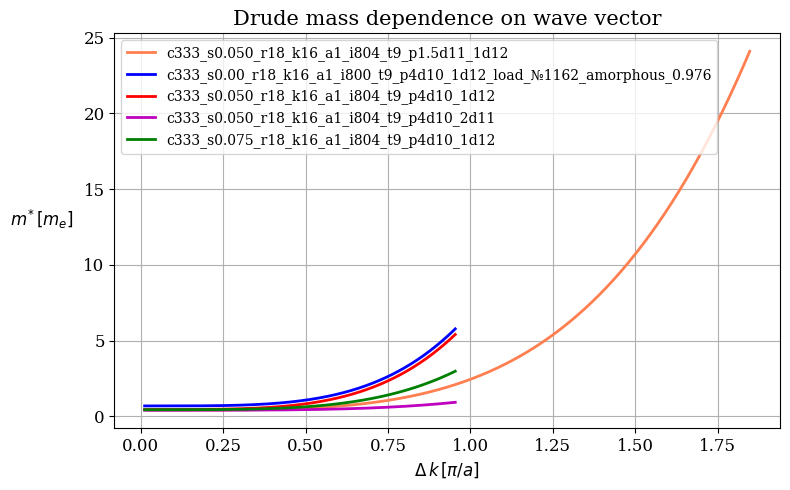

In [113]:
colors=['coral', 'b', 'r', 'm', 'g', 'orange', 'gold', 'purple', 'slateblue', 'olive', 'navy', 'darkred']

if len(sorted_folders)<12:


    plt.figure(figsize=(8,5))
    plt.title("Drude mass dependence on wave vector", fontsize=15)
    
    
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    
    plt.legend(fontsize=12)
    
    plot_part=1
    num_folder=0
    for (a0, b0, c0) in arr_abc:
        num_folder+=1
        if num_folder!=0:
            plt.plot(np.linspace(alphas_start[num_folder-1], plot_part*alphas_final[num_folder-1], 500), 
            [17.56*get_n_excited_electrons(sorted_folders[num_folder-1])[0]/effecive_mass_model(a, a0, b0, c0) for a in np.linspace(alphas_start[num_folder-1], 
            plot_part*alphas_final[num_folder-1], 500)], label=sorted_folders[num_folder-1], linewidth=2, color=colors[num_folder-1])

    j=j+1
    plt.grid()
    plt.legend()
    plt.xlabel(r'$\Delta \, k \, [\pi/a]$', fontsize=12)
    # plt.ylabel(r'$\dfrac{m$^*$}{n}$ [a.u.]')
    # plt.ylabel(r'$\dfrac{m}{n}\, [a.u.]$', rotation=0,  labelpad=30)
    plt.ylabel(r'$m^{*}\, [m_e]$', fontsize=12, rotation=0,  labelpad=30)
    plt.tight_layout()
    
    plt.savefig("all_data/drude/ims/png/" + 'drude_m_dependence.png', dpi=200)
    plt.savefig("all_data/drude/ims/pdf/" + 'drude_m_dependence.pdf', bbox_inches="tight")

    print("Effective mass plots are completed")
    print(" ")


    
    # plt.savefig("drude_mass_adj/" + "Mass_Dependence_on_disorder" + ".png", dpi=200, bbox_inches='tight')

In [114]:
num_folder=0
for (a0, b0, c0) in arr_abc:
    num_folder+=1

    delta_k_vals = np.linspace(alphas_start[num_folder-1], plot_part*alphas_final[num_folder-1], 500)
    
    effective_mass_vals = [17.56*get_n_excited_electrons(sorted_folders[num_folder-1])[0]/effecive_mass_model(a, a0, b0, c0) for a in np.linspace(alphas_start[num_folder-1], 
    plot_part*alphas_final[num_folder-1], 500)]
    
    effective_mass_data=np.array([delta_k_vals, effective_mass_vals])

    columns = ["delta_k",  "effective_mass"]
    df = pd.DataFrame(effective_mass_data.T, columns=columns)
    
    
    df.to_csv("all_data/drude/data/m/" + str(num_folder)+ "_effective_mass_" + sorted_folders[num_folder-1] + ".csv", index=False)
    
    with open("all_data/drude/data/m/" + str(num_folder)+ "_effective_mass_" + sorted_folders[num_folder-1] + ".csv", "w") as f:
        f.write(r"# Units: Wave vector during the probe pulse $\Delta k$ [$\pi/a$], Effective mass $m^{*}$ [$m_e$]" + "\n")
        df.to_csv(f, index=False)
    
    print("For " + sorted_folders[num_folder-1] + " effective mass data saving in csv format is completed")


print(" ")

For c333_s0.050_r18_k16_a1_i804_t9_p1.5d11_1d12 effective mass data in csv format is completed
For c333_s0.00_r18_k16_a1_i800_t9_p4d10_1d12_load_№1162_amorphous_0.976 effective mass data in csv format is completed
For c333_s0.050_r18_k16_a1_i804_t9_p4d10_1d12 effective mass data in csv format is completed
For c333_s0.050_r18_k16_a1_i804_t9_p4d10_2d11 effective mass data in csv format is completed
For c333_s0.075_r18_k16_a1_i804_t9_p4d10_1d12 effective mass data in csv format is completed
 


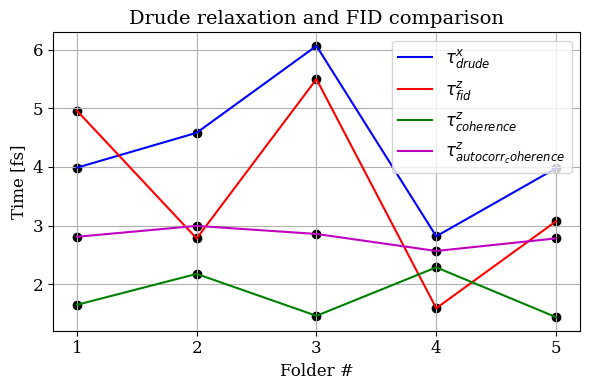

In [211]:
plt.figure(figsize=(6, 4))

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.legend(fontsize=12)

plt.title("Drude relaxation and FID comparison", fontsize=14)
folder_nums = np.linspace(1, len(new_taus), len(new_taus))
plt.plot(folder_nums, new_taus, color='b', label=r'$\tau_{drude}^x$')
plt.plot(folder_nums, tau_fid_z_arr, color='r', label=r'$\tau_{fid}^z$')

plt.plot(folder_nums, np.array(mandels_coherence_arr), color='g', label=r'$\tau_{coherence}^z$')
plt.scatter(folder_nums, np.array(mandels_coherence_arr), color='black')


plt.plot(folder_nums, np.array(auto_corr_mandels_coherence), color='m', label=r'$\tau_{autocorr_coherence}^z$')
plt.scatter(folder_nums, np.array(auto_corr_mandels_coherence), color='black')

plt.scatter(folder_nums, new_taus, color='black')
plt.scatter(folder_nums, tau_fid_z_arr, color='black')
plt.ylabel("Time [fs]", fontsize=12)
plt.xlabel("Folder #", fontsize=12)
plt.xticks(folder_nums)
plt.legend(fontsize=12)
plt.grid()
plt.tight_layout()

plt.savefig("all_data/fid/" + 'tau_comparison.png', dpi=200)
plt.savefig("all_data/fid/" + 'tau_comparison.pdf', bbox_inches="tight")

## draft

In [18]:
# folder = sorted_folders[0]

# # Загрузка данных, пропуская строки с комментариями (начинаются с #)
# pulse_data_both = pd.read_csv(
#     folder + '/both_pulses_pulse.data',
#     comment='#',
#     delim_whitespace=True,
#     header=None
# )

# pulse_data_pump = pd.read_csv(
#     folder + '/pump_pulse_pulse.data',
#     comment='#',
#     delim_whitespace=True,
#     header=None
# )

# pulse_data_probe = pd.read_csv(
#     folder + '/probe_pulse_pulse.data',
#     comment='#',
#     delim_whitespace=True,
#     header=None
# )


# pulse_data_both.columns = [
#     'Energy_eV',

#     'Re_Jm_x', 'Re_Jm_y', 'Re_Jm_z',
#     'Im_Jm_x', 'Im_Jm_y', 'Im_Jm_z',
#     'Abs2_Jm_x', 'Abs2_Jm_y', 'Abs2_Jm_z',

#     'Re_El_f_Ext_x', 'Re_El_f_Ext_y', 'Re_El_f_Ext_z',
#     'Im_El_f_Ext_x', 'Im_El_f_Ext_y', 'Im_El_f_Ext_z',
#     'Abs2_El_f_Ext_x', 'Abs2_El_f_Ext_y', 'Abs2_El_f_Ext_z',

#     'Re_El_f_Tot_x', 'Re_El_f_Tot_y', 'Re_El_f_Tot_z',
#     'Im_El_f_Tot_x', 'Im_El_f_Tot_y', 'Im_El_f_Tot_z',
#     'Abs2_El_f_Tot_x', 'Abs2_El_f_Tot_y', 'Abs2_El_f_Tot_z'
# ]

# pulse_data_pump.columns  = pulse_data_both.columns

# pulse_data_probe.columns = pulse_data_both.columns


# energies = pulse_data_both['Energy_eV']


# Abs2_Jm_both_z  =  pulse_data_both['Abs2_Jm_z']
# Abs2_Jm_pump_z  =  pulse_data_pump['Abs2_Jm_z']
# Abs2_Jm_probe_z =  pulse_data_probe['Abs2_Jm_z']

# Abs2_Jm_both_x  =  pulse_data_both['Abs2_Jm_x']
# Abs2_Jm_pump_x  =  pulse_data_pump['Abs2_Jm_x']
# Abs2_Jm_probe_x =  pulse_data_probe['Abs2_Jm_x']

# Abs2_Jm_both_y  =  pulse_data_both['Abs2_Jm_y']
# Abs2_Jm_pump_y  =  pulse_data_pump['Abs2_Jm_y']
# Abs2_Jm_probe_y =  pulse_data_probe['Abs2_Jm_y']

In [349]:
# plt.plot(energies, Abs2_Jm_both_x, color='b')
# plt.plot(energies, Abs2_Jm_pump_x, color='r')
# plt.plot(energies, Abs2_Jm_probe_x, color='g')
# plt.xlim(0, 6)
# plt.ylim(0, 0.0001)

## draft

In [350]:
# def effecive_mass_model(alpha, a, b, c):
#     return 1/(a**2 * alpha**4 + 0*alpha + c)

In [351]:
# def generalized_drude_current_v8_tau_j_final_free_mass_adjustment(dummy_t, j0, a, b, c, tau, j_final, idx):

    
#     data_both = pd.read_csv(
#         folder + '/both_pulses_rt.data',
#         comment='#',
#         delim_whitespace=True,
#         header=None
#     )
    
    
#     data_both.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
#         'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
#         'Jm_x', 'Jm_y', 'Jm_z']
    
#     t = data_both['time_fs']
#     El_f_probe_x = data_both['E_ext_x']
    
    
#     step_dt = 0.002
    
#     m0_cut_2 = 6250
    
#     dt = np.diff(t, prepend=t[0])
    
    
#     alpha_E_t = np.cumsum(-2.64*El_f_probe_x[5250:]*dt[5250:])
#     fit_alpha_E_t = alpha_E_t[1000:]
    
#     alpha_fit = np.array(effecive_mass_model(fit_alpha_E_t, a, b, c))
    
    
    
#     # --- Задаём поле в дискретных точках ---
#     t_array = np.array(t[m0_cut_2:])         # сетка времени
#     E_array = -np.array(El_f_probe_x[m0_cut_2:]) 
    
        
#     # --- Решение через явный шаг Эйлера ---
    
#     j_euler = np.zeros_like(t_array)
#     j_euler[0] = j0
    
#     for k in range(len(t_array)-1):
#         j_euler[k+1] = j_euler[k] + step_dt * (-(j_euler[k]-j_final)/tau + alpha_fit[k] * E_array[k])

    
#     return j_euler[::1]

In [257]:
get_n_excited_electrons(sorted_folders[0])[0]

np.float64(0.0011414111146725592)

In [258]:
sorted_folders

['c333_s0.050_r18_k16_a1_i804_t9_p1.5d11_1d12',
 'c333_s0.00_r18_k16_a1_i800_t9_p4d10_1d12_load_№1162_amorphous_0.976',
 'c333_s0.050_r18_k16_a1_i804_t9_p4d10_1d12',
 'c333_s0.050_r18_k16_a1_i804_t9_p4d10_2d11',
 'c333_s0.075_r18_k16_a1_i804_t9_p4d10_1d12']

In [352]:
# plt.figure(figsize=(8,5))
# plt.title("Drude factor dependence on disorder")

# plot_part=1
# num_folder=0
# for (a0, b0, c0) in arr_abc:
#     num_folder+=1
#     if num_folder!=0:
#         plt.plot(np.linspace(alphas_start[num_folder-1], plot_part*alphas_final[num_folder-1], 500), [17.56*get_n_excited_electrons(sorted_folders[num_folder-1])[0]/effecive_mass_model(a, a0, b0, c0) for a in np.linspace(alphas_start[num_folder-1], plot_part*alphas_final[num_folder-1], 500)], label=sorted_folders[num_folder-1], linewidth=2)

# plt.grid()
# plt.legend()
# plt.xlabel(r'$\Delta \, k \, [\pi/a]$')
# # plt.ylabel(r'$\dfrac{m$^*$}{n}$ [a.u.]')
# # plt.ylabel(r'$\dfrac{m}{n}\, [a.u.]$', rotation=0,  labelpad=30)
# plt.ylabel(r'$m^{*}\, [m_e]$', rotation=0,  labelpad=30)
# plt.show()

# # plt.savefig("drude_mass_adj/" + "Mass_Dependence_on_disorder" + ".png", dpi=200, bbox_inches='tight')

## draft FID

In [353]:
# new_taus = []
# new_j_finals = []
# arr_abc = []

    
# folder = sorted_folders[0]

# # Загрузка данных, пропуская строки с комментариями (начинаются с #)
# data_both = pd.read_csv(
#     folder + '/both_pulses_rt.data',
#     comment='#',
#     delim_whitespace=True,
#     header=None
# )


# data_probe = pd.read_csv(
#     folder + '/probe_pulse_rt.data',
#     comment='#',
#     delim_whitespace=True,
#     header=None
# )


# data_pump = pd.read_csv(
#     folder + '/pump_pulse_rt.data',
#     comment='#',
#     delim_whitespace=True,
#     header=None
# )


# # Назначим читаемые имена колонкам
# data_both.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
#     'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
#     'Jm_x', 'Jm_y', 'Jm_z']

# data_probe.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
#     'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
#     'Jm_x', 'Jm_y', 'Jm_z']

# data_pump.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
#     'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
#     'Jm_x', 'Jm_y', 'Jm_z']


# t = data_both['time_fs']


# Jm_both_z  =  data_both['Jm_z']

# Jm_both_x  =  data_both['Jm_x']
# Jm_pump_x  =  data_pump['Jm_x']
# Jm_probe_x =  data_probe['Jm_x']

# Jm_both_y  =  data_both['Jm_y']
# Jm_pump_y  =  data_pump['Jm_y']
# Jm_probe_y =  data_probe['Jm_y']


# El_f_pump_z = data_both['E_ext_z']
# El_f_probe_x = data_both['E_ext_x']


# # fixed_generalized_drude_current_v2 = partial(generalized_drude_current_v2, arr_j_finals=j_finals, arr_alphas=alphas, arr_taus=taus, idx=num_folder)


# fixed_generalized_drude_current_v8_tau_j_final_free_mass_adjustment = partial(generalized_drude_current_v8_tau_j_final_free_mass_adjustment, idx=num_folder)



# delta_Jm_x = Jm_both_x - Jm_probe_x - Jm_pump_x

# # t_array_cut = np.array(t[m0_cut_2:])[::50]
# # j_exp = np.array(delta_Jm_x[m0_cut_2:])[::50]
# # # (dummy_t, j0, fit_alpha, j_final)
# # p0 = [0.03, 0.2]   # начальные приближения (n, tau)
# # # print(len(t_array_cut), len(j_exp))
# # popt, pcov = curve_fit(fixed_generalized_drude_current_v2, t_array_cut, j_exp, p0=p0)
# # j0, fit_alpha = popt
# # j_fit = fixed_generalized_drude_current_v2(0, j0, fit_alpha)

# plt.figure(figsize=(8,5))
# plt.title(' '.join(re.split('[/_]', folder)), fontsize=14, y=1.03)
# plt.plot(t, delta_Jm_x, color='b')
# # plt.plot(t_array_cut, j_fit, '-', label=r'Gen. Drude $\tau$', color='r')
# plt.xlabel("Time [fs]")
# plt.ylabel("J [$fs^{-1} \\cdot Å^{-2}$]")


# t_array_cut = np.array(t[m0_cut_2:])[::1]
# j_exp = np.array(delta_Jm_x[m0_cut_2:])[::1]
# # (dummy_t, j0, fit_alpha, j_final)
# p0 = [0.04, 2, 0, 5, 5, 0]   # начальные приближения (n, tau)
# # print(len(t_array_cut), len(j_exp))
# popt, pcov = curve_fit(fixed_generalized_drude_current_v8_tau_j_final_free_mass_adjustment, t_array_cut, j_exp, p0=p0, bounds = (
# [-np.inf, 0, -np.inf, -np.inf, 0, -np.inf],[ np.inf, 20, np.inf, np.inf, np.inf, np.inf]
# ))
# j0, a, b, c, fit_tau_val, fit_j_fin_val = popt
# j_fit = fixed_generalized_drude_current_v8_tau_j_final_free_mass_adjustment(0, j0, a, b, c, fit_tau_val, fit_j_fin_val)

# new_taus.append(fit_tau_val)
# new_j_finals.append(fit_j_fin_val)

# plt.plot(t_array_cut, j_fit, '-', label=r'Gen. Drude $m^*$', color='r')
# plt.legend()
# plt.grid()
# arr_abc.append((a, b, c))
# print(a, b, c)

In [354]:
# import numpy as np
# import pandas as pd
# from scipy.interpolate import CubicSpline

# def build_nonFID_component_with_zero_plateau(
#     t,                 # pd.Series или np.ndarray, полная сетка времени
#     t_array_cut,       # np.ndarray, время для друде-фита (начиная ~12.5 fs)
#     j_fit,             # np.ndarray, значения друде-фита
#     t_zero_end=9.0,    # fs: до этого времени nonFID принудительно 0
#     halfmax=0.5,       # t1 = первая точка, где j_fit >= halfmax*max
# ):
#     t_full = np.asarray(t, dtype=float)
#     t_cut = np.asarray(t_array_cut, dtype=float)
#     j_cut = np.asarray(j_fit, dtype=float)

#     if t_cut.shape != j_cut.shape:
#         raise ValueError("t_array_cut и j_fit должны быть одинаковой длины.")

#     # сортировка на всякий случай
#     order = np.argsort(t_cut)
#     t_cut = t_cut[order]
#     j_cut = j_cut[order]

#     # --- t1 по halfmax ---
#     jmax = np.nanmax(j_cut)
#     if not np.isfinite(jmax) or jmax == 0:
#         raise ValueError("j_fit выглядит нулевым/некорректным (max=0 или NaN).")

#     thresh = halfmax * jmax
#     idxs = np.flatnonzero(j_cut >= thresh)
#     if len(idxs) == 0:
#         raise ValueError("Не нашёл точку, где j_fit >= halfmax * max(j_fit).")
#     i1 = idxs[0]
#     if i1 >= len(j_cut) - 1:
#         raise ValueError("Точка halfmax слишком близко к концу — нельзя оценить производную.")

#     t1 = t_cut[i1]
#     y1 = j_cut[i1]
#     dydt1 = (j_cut[i1 + 1] - j_cut[i1]) / (t_cut[i1 + 1] - t_cut[i1])

#     # проверка, что зона нулевого плато действительно раньше стыка
#     if t1 <= t_zero_end:
#         raise ValueError(
#             f"Получилось t1={t1:.3g} fs <= t_zero_end={t_zero_end:.3g} fs. "
#             "Нужно уменьшить t_zero_end или иначе выбирать t1."
#         )

#     # --- полиномное включение, но начиная с t_zero_end ---
#     # Используем τ = t - t0z, где t0z = t_zero_end
#     # y(τ) = a τ^3 + b τ^2
#     # y(0)=0 и y'(0)=0 автоматически
#     # Подбираем a,b так, чтобы в τ1 = (t1 - t0z): y=y1 и dy/dt = dydt1
#     tau1 = t1 - t_zero_end
#     a = (dydt1 * tau1 - 2.0 * y1) / (tau1**3)
#     b = (3.0 * y1 - dydt1 * tau1) / (tau1**2)

#     nonFID = np.zeros_like(t_full)

#     # t <= t_zero_end : строго 0
#     # t_zero_end < t < t1 : полином по τ
#     s_poly = (t_full > t_zero_end) & (t_full < t1)
#     tau = t_full[s_poly] - t_zero_end
#     nonFID[s_poly] = a * tau**3 + b * tau**2

#     # t >= t1 : сплайн по Drude fit (с экстраполяцией)
#     spline = CubicSpline(t_cut, j_cut, extrapolate=True)
#     s_spline = t_full >= t1
#     nonFID[s_spline] = spline(t_full[s_spline])

#     info = {
#         "t_zero_end": t_zero_end,
#         "t1": t1,
#         "y1": y1,
#         "dydt1": dydt1,
#         "a": a,
#         "b": b,
#         "halfmax": halfmax,
#     }
#     return nonFID, info


# def subtract_nonFID_and_get_FID_with_zero_plateau(
#     t, delta_Jm_x, t_array_cut, j_fit, t_zero_end=9.0, halfmax=0.5
# ):
#     nonFID, info = build_nonFID_component_with_zero_plateau(
#         t=t,
#         t_array_cut=t_array_cut,
#         j_fit=j_fit,
#         t_zero_end=t_zero_end,
#         halfmax=halfmax,
#     )

#     if isinstance(delta_Jm_x, pd.Series):
#         fid_vals = delta_Jm_x.values - nonFID
#         fid = pd.Series(fid_vals, index=delta_Jm_x.index, name="FID_component")
#         nonFID_out = pd.Series(nonFID, index=delta_Jm_x.index, name="nonFID_component")
#     else:
#         fid = np.asarray(delta_Jm_x, dtype=float) - nonFID
#         nonFID_out = nonFID

#     return fid, nonFID_out, info


In [355]:
# fid, nonFID, info = subtract_nonFID_and_get_FID_with_zero_plateau(
#     t=t,
#     delta_Jm_x=delta_Jm_x,
#     t_array_cut=t_array_cut,
#     j_fit=j_fit,
#     t_zero_end=8.5,   # твоя физическая “ноль-зона”
#     halfmax=0.85
# )

# plt.figure()
# plt.plot(t, delta_Jm_x, label="raw ΔJ")
# plt.plot(t, nonFID, label="non-FID (forced 0 until 9 fs)")
# plt.plot(t, fid, label="FID")
# # plt.plot(t_array_cut, j_fit, '-', label=r'Gen. Drude $m^*$', color='r')
# plt.axvline(info["t_zero_end"], linestyle="--", label="t_zero_end")
# # plt.axvline(info["t1"], linestyle="--", label="t1")
# # plt.legend()
# plt.xlabel("t (fs)")
# plt.show()

In [356]:
# import scipy

# fid, nonFID, info = subtract_nonFID_and_get_FID_with_zero_plateau(
#     t=t,
#     delta_Jm_x=delta_Jm_x,
#     t_array_cut=t_array_cut,
#     j_fit=j_fit,
#     t_zero_end=8.5,   # твоя физическая “ноль-зона”
#     halfmax=0.85
# )

# print("Mandel's coherence time: ",coherence_time(fid, 0.002))
# print("Drude relaxation time: ", fit_tau_val)

# plt.figure()
# plt.plot(t, delta_Jm_x, label="raw ΔJ")
# plt.plot(t, nonFID, label="non-FID (forced 0 until 9 fs)")
# plt.plot(t, fid, label="FID", color='b')
# plt.plot(t_array_cut, j_fit, '-', label=r'Gen. Drude $m^*$', color='r')
# # plt.axvline(info["t_zero_end"], linestyle="--", label="t_zero_end")
# # plt.axvline(info["t1"], linestyle="--", label="t1")
# # plt.legend()
# plt.xlabel("t (fs)")
# plt.show()

In [357]:
# fid, nonFID, info = subtract_nonFID_and_get_FID_with_zero_plateau(
#     t=t,
#     delta_Jm_x=delta_Jm_x,
#     t_array_cut=t_array_cut,
#     j_fit=j_fit,
#     t_zero_end=10.5,   # твоя физическая “ноль-зона”
#     halfmax=0.5
# )

# plt.figure()
# plt.plot(t, delta_Jm_x, label="raw ΔJ")
# plt.plot(t, nonFID, label="non-FID (forced 0 until 9 fs)")
# plt.plot(t, fid, label="FID")
# plt.plot(t_array_cut, j_fit, '-', label=r'Gen. Drude $m^*$', color='r')
# plt.axvline(info["t_zero_end"], linestyle="--", label="t_zero_end")
# plt.axvline(info["t1"], linestyle="--", label="t1")
# plt.legend()
# plt.xlabel("t (fs)")
# plt.show()

In [358]:
# def coherence_time(Y, dt) -> float:
#     r"""
#     Given a signal Y(t) on an equidistant grid, the function estimates the coherence time.

#     The function implements Mandel's coherence time. It calculates the autocorrelation
#     function of the given signal, then it calculates the complex envelope of the
#     autocorrelation function, and integrates the square of the normalized envelope from
#     t=0 to the maximal time. The coherence time is twice the value of the integral.

#     Args:
#       Y: 1D array that represents the time-dependent signal on a regular grid.
#       dt: Time step of the grid.

#     Returns:
#       the coherence time as a floating-point number.
#     """
#     ACF = scipy.signal.correlate(Y, Y, mode="full", method="direct") # autocorrelation function
#     N = len(Y)
#     # X = dt * np.arange(-(N - 1), N) # DEBUGGING
#     ACF_envelope = np.abs(scipy.signal.envelope(ACF, residual=None))
#     ACF_envelope /= np.max(ACF_envelope)
#     i1 = N - 1 # np.flatnonzero(X >= 0)[0]
#     # print("X[i1] =", X[i1]) # DEBUGGING
#     return 2.0 * scipy.integrate.simpson(ACF_envelope[i1:]**2, dx=dt)

## draft v2

In [359]:

# folder = sorted_folders[0]
# ax = 'z'
# j = 0


# # Загрузка данных, пропуская строки с комментариями (начинаются с #)
# data_both = pd.read_csv(
#     folder + '/both_pulses_rt.data',
#     comment='#',
#     delim_whitespace=True,
#     header=None
# )

# data_pump = pd.read_csv(
#     folder + '/pump_pulse_rt.data',
#     comment='#',
#     delim_whitespace=True,
#     header=None
# )

# data_probe = pd.read_csv(
#     folder + '/probe_pulse_rt.data',
#     comment='#',
#     delim_whitespace=True,
#     header=None
# )


# # Назначим читаемые имена колонкам
# data_both.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
#     'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
#     'Jm_x', 'Jm_y', 'Jm_z']

# data_pump.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
#     'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
#     'Jm_x', 'Jm_y', 'Jm_z']

# data_probe.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
#     'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
#     'Jm_x', 'Jm_y', 'Jm_z']


# t = data_both['time_fs']


# Jm_both_z  =  data_both['Jm_z']

# Jm_both_x  =  data_both['Jm_x']
# Jm_pump_x  =  data_pump['Jm_x']
# Jm_probe_x =  data_probe['Jm_x']

# Jm_both_y  =  data_both['Jm_y']
# Jm_pump_y  =  data_pump['Jm_y']
# Jm_probe_y =  data_probe['Jm_y']


# El_f_pump_z = data_both['E_ext_z']
# El_f_probe_x = data_both['E_ext_x']


# # 1:Time[fs] 2:Ac_ext_x[fs*V/Angstrom] 3:Ac_ext_y[fs*V/Angstrom] 4:Ac_ext_z[fs*V/Angstrom]
# #5:E_ext_x[V/Angstrom] 6:E_ext_y[V/Angstrom] 7:E_ext_z[V/Angstrom] 8:Ac_tot_x[fs*V/Angstrom]
# # 9:Ac_tot_y[fs*V/Angstrom] 10:Ac_tot_z[fs*V/Angstrom] 11:E_tot_x[V/Angstrom]
# # 12:E_tot_y[V/Angstrom] 13:E_tot_z[V/Angstrom]  14:Jm_x[1/fs*Angstrom^2] 15:Jm_y[1/fs*Angstrom^2] 16:Jm_z[1/fs*Angstrom^2]


# # Построим графики
# plt.figure(figsize=(10, 12.5))

# # Общий заголовок для всей фигуры
# plt.suptitle(' '.join(re.split('[/_]', folder)), fontsize=14, y=0.99)

# # Первый график: внешнее поле по z
# plt.subplot(5, 2, 1)
# plt.plot(t, El_f_pump_z, label='E_ext_z', color='#2CD311')
# plt.xlabel('Time [fs]')
# plt.ylabel('E [V/Å]')
# plt.title('Pump external electric field z')
# plt.grid(True)
# #plt.legend()
# plt.tight_layout()

# # Второй график: внешнее поле по x
# plt.subplot(5, 2, 2)
# plt.plot(t, El_f_probe_x, label='E_ext_z', color='c')
# plt.xlabel('Time [fs]')
# plt.ylabel('E [V/Å]')
# plt.title('Probe external electric field x')
# plt.grid(True)
# #plt.legend()
# plt.tight_layout()

# # Четвертый график: суммарный ток по z
# plt.subplot(5, 2, 4)
# plt.plot(t, Jm_both_z, color='magenta')
# plt.xlabel('Time [fs]')
# plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
# plt.title('Full matter current density along z')
# plt.grid(True)

# plt.tight_layout()



# product_both_z = El_f_pump_z * Jm_both_z * volume
# # Разность по времени
# dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
# integral_both_z = np.cumsum(product_both_z * dt)

# product_both_x = El_f_probe_x * Jm_both_x * volume
# # Разность по времени
# dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
# integral_both_x = np.cumsum(product_both_x * dt)

# product_delta_x = El_f_probe_x * (Jm_both_x - Jm_pump_x - Jm_probe_x) * volume
# # Разность по времени
# dt = np.diff(t, prepend=t[0])  # prepend чтобы сохранить размер
# integral_delta_x = np.cumsum(product_delta_x * dt)



# # Построение графика изменения энергии во времени
# plt.subplot(5, 2, 3)
# # plt.plot(energy_data['Time_fs'], energy_data['Delta_E_eV'], label='ΔE = E_total - E_initial', color='r')
# plt.plot(t, -integral_both_z, label='ΔE = E_total - E_initial', color='r')
# plt.xlabel('Time [fs]')
# plt.ylabel('E [eV]')
# plt.title('Energy transfer per unit cell along z')
# plt.grid(True)
# #plt.legend()
# plt.tight_layout()



# # Построение графика изменения энергии во времени
# plt.subplot(5, 2, 5)
# # plt.plot(energy_data['Time_fs'], energy_data['Delta_E_eV'], label='ΔE = E_total - E_initial', color='r')
# plt.plot(t, -integral_both_x, label='ΔE = E_total - E_initial', color='blue')
# plt.xlabel('Time [fs]')
# plt.ylabel('E [eV]')
# plt.title('Energy transfer per unit cell along x')
# plt.grid(True)
# #plt.legend()
# plt.tight_layout()


# # Построение графика изменения энергии во времени
# plt.subplot(5, 2, 6)
# # plt.plot(energy_data['Time_fs'], energy_data['Delta_E_eV'], label='ΔE = E_total - E_initial', color='r')
# plt.plot(t, -integral_delta_x, label='ΔE = E_total - E_initial', color='black')
# plt.xlabel('Time [fs]')
# plt.ylabel('E [eV]')
# plt.title('Δ energy transfer per unit cell along x')
# plt.grid(True)
# #plt.legend()
# plt.tight_layout()



# # Суммарный ток по x
# plt.subplot(5, 2, 7)
# plt.plot(t, Jm_both_x, color='#DC143C')
# plt.xlabel('Time [fs]')
# plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
# plt.title('Full matter current density along x')
# plt.grid(True)
# plt.tight_layout()




# delta_Jm_x = Jm_both_x - Jm_pump_x - Jm_probe_x


# t_array_cut = np.array(t[m0_cut_1:])[::50]
# j_exp = np.array(delta_Jm_x[m0_cut_1:])[::50]
# # (dummy_t, j0, j_final, tau)
# p0 = [0.03, 0.01, 6.65]   # начальные приближения (n, tau)
# popt, pcov = curve_fit(drude_current_v1, t_array_cut, j_exp, p0=p0)
# j0, j_final, tau= popt
# j_fit = drude_current_v1(0, j0, j_final, tau)

# ratio = j_final/max(delta_Jm_x)

# # Разностный ток по x
# plt.subplot(5, 2, 8)
# plt.plot(t, (Jm_both_x - Jm_pump_x - Jm_probe_x), color='#00FF7F')
# plt.plot(t_array_cut, j_fit, '--', label=rf"$\tau = {tau:.2f}\ \mathrm{{fs}} \quad j_{{\rm final}} : j_{{\rm max}} = {ratio:.2f}$", color='r')
# plt.xlabel('Time [fs]')
# plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
# plt.title('Δ matter current density along x')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()




# # Суммарный ток по y
# plt.subplot(5, 2, 9)
# plt.plot(t, Jm_both_y, color='#00BFFF')
# plt.xlabel('Time [fs]')
# plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
# plt.title('Full matter current density along y')
# plt.grid(True)
# plt.tight_layout()


# # Разностный ток по y
# plt.subplot(5, 2, 10)
# plt.plot(t, (Jm_both_y - Jm_pump_y - Jm_probe_y), color='#FF007F')
# plt.xlabel('Time [fs]')
# plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
# plt.title('Δ matter current density along y')
# plt.grid(True)
# plt.tight_layout()





# # lr_data = pd.read_csv(
# #     folder + '/lr_response.data',
# #     comment='#',
# #     delim_whitespace=True,
# #     header=None
# # )

# # lr_data.columns = [
# #     'Energy',        # 1
# #     'Re_sigma_x',    # 2
# #     'Re_sigma_y',    # 3
# #     'Re_sigma_z',    # 4
# #     'Im_sigma_x',    # 5
# #     'Im_sigma_y',    # 6
# #     'Im_sigma_z',    # 7
# #     'Re_eps_x',      # 8
# #     'Re_eps_y',      # 9
# #     'Re_eps_z',      # 10
# #     'Im_eps_x',      # 11
# #     'Im_eps_y',      # 12
# #     'Im_eps_z',      # 13
# # ]


# # # Построение графика изменения энергии во времени
# # plt.subplot(5, 2, 9)
# # plt.plot(lr_data['Energy'][100:], lr_data['Im_eps_z'][100:], label='Im(ε)', color='#00BFFF')
# # plt.xlabel('E [eV]')
# # plt.ylabel('Im(ε)')
# # plt.title('Absorption')
# # plt.grid(True)
# # #plt.legend()
# # plt.tight_layout()

# # # Построение графика изменения энергии во времени
# # plt.subplot(5, 2, 10)
# # plt.plot(lr_data['Energy'][100:], lr_data['Re_eps_z'][100:], label='Re(ε)', color='#FF007F')
# # plt.xlabel('E [eV]')
# # plt.ylabel('Re(ε)')
# # plt.title('Dispersion')
# # plt.grid(True)
# # #plt.legend()
# # plt.tight_layout()
# # # plt.show()

# # plt.savefig("ims/all/" + folder + ".pdf")
# # plt.savefig("ims/all/" + str(j)+ '_' + folder + ".png", dpi=200)

# dt = np.diff(t, prepend=t[0])

# arr = np.array(np.cumsum(-2.64*El_f_probe_x[m0_cut_3:m0_cut_1+1000]*dt[m0_cut_3:m0_cut_1+1000]))
# a_start = arr[m0_cut_2-m0_cut_3]
# a_fin = arr[-1]




# # In[ ]:


In [360]:

# for folder in sorted_folders:

#     # folder = sorted_folders[0]
#     ax = 'z'
#     j = 0


#     # Загрузка данных, пропуская строки с комментариями (начинаются с #)
#     data_both = pd.read_csv(
#         folder + '/both_pulses_rt.data',
#         comment='#',
#         delim_whitespace=True,
#         header=None
#     )
    
#     data_pump = pd.read_csv(
#         folder + '/pump_pulse_rt.data',
#         comment='#',
#         delim_whitespace=True,
#         header=None
#     )
    
#     data_probe = pd.read_csv(
#         folder + '/probe_pulse_rt.data',
#         comment='#',
#         delim_whitespace=True,
#         header=None
#     )
    
    
#     # Назначим читаемые имена колонкам
#     data_both.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
#         'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
#         'Jm_x', 'Jm_y', 'Jm_z']
    
#     data_pump.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
#         'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
#         'Jm_x', 'Jm_y', 'Jm_z']
    
#     data_probe.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
#         'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
#         'Jm_x', 'Jm_y', 'Jm_z']
    
    
#     t = data_both['time_fs']
    
    
#     Jm_both_z  =  data_both['Jm_z']
    
#     Jm_both_x  =  data_both['Jm_x']
#     Jm_pump_x  =  data_pump['Jm_x']
#     Jm_probe_x =  data_probe['Jm_x']
    
#     Jm_both_y  =  data_both['Jm_y']
#     Jm_pump_y  =  data_pump['Jm_y']
#     Jm_probe_y =  data_probe['Jm_y']
    
    
#     El_f_pump_z = data_both['E_ext_z']
#     El_f_probe_x = data_both['E_ext_x']
    
    
#     plt.figure(figsize=(6, 4))
#     print(folder)
#     plt.plot(t, El_f_probe_x/20, color='g')
#     plt.plot(t, Jm_pump_x, color='b')
#     plt.plot(t, Jm_both_x, color='r')
#     plt.plot(t, Jm_probe_x, color='#00BFFF')
#     plt.plot(t, Jm_both_x-Jm_pump_x-Jm_probe_x, color='black')
#     plt.xlabel('Time [fs]')
#     plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
#     plt.title('Full matter current density along x,  probe')
#     plt.grid(True)
#     plt.tight_layout()

In [361]:

# for folder in sorted_folders:

#     # folder = sorted_folders[0]
#     ax = 'z'
#     j = 0


#     # Загрузка данных, пропуская строки с комментариями (начинаются с #)
#     data_both = pd.read_csv(
#         folder + '/both_pulses_rt.data',
#         comment='#',
#         delim_whitespace=True,
#         header=None
#     )
    
#     data_pump = pd.read_csv(
#         folder + '/pump_pulse_rt.data',
#         comment='#',
#         delim_whitespace=True,
#         header=None
#     )
    
#     data_probe = pd.read_csv(
#         folder + '/probe_pulse_rt.data',
#         comment='#',
#         delim_whitespace=True,
#         header=None
#     )
    
    
#     # Назначим читаемые имена колонкам
#     data_both.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
#         'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
#         'Jm_x', 'Jm_y', 'Jm_z']
    
#     data_pump.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
#         'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
#         'Jm_x', 'Jm_y', 'Jm_z']
    
#     data_probe.columns = ['time_fs', 'Ac_ext_x', 'Ac_ext_y', 'Ac_ext_z', 'E_ext_x', 'E_ext_y', 'E_ext_z',         
#         'Ac_tot_x', 'Ac_tot_y', 'Ac_tot_z', 'E_tot_x', 'E_tot_y', 'E_tot_z',         
#         'Jm_x', 'Jm_y', 'Jm_z']
    
    
#     t = data_both['time_fs']
    
    
#     Jm_both_z  =  data_both['Jm_z']
#     Jm_pump_z  =  data_pump['Jm_z']
    
#     Jm_both_x  =  data_both['Jm_x']
#     Jm_pump_x  =  data_pump['Jm_x']
#     Jm_probe_x =  data_probe['Jm_x']
    
#     Jm_both_y  =  data_both['Jm_y']
#     Jm_pump_y  =  data_pump['Jm_y']
#     Jm_probe_y =  data_probe['Jm_y']
    
    
#     El_f_pump_z = data_both['E_ext_z']
#     El_f_probe_x = data_both['E_ext_x']
    
    
#     plt.figure(figsize=(6, 4))
#     print(folder)
#     # plt.plot(t, El_f_probe_x/20, color='g')
#     plt.plot(t, Jm_both_z/5, color='b')
#     plt.plot(t, Jm_pump_z/5, color='black')
#     plt.plot(t, Jm_pump_z-Jm_both_z, color='r')
#     # plt.plot(t, Jm_both_y, color='r')
#     # plt.plot(t, Jm_probe_y, color='#00BFFF')
#     # plt.plot(t, Jm_both_x-Jm_pump_x-Jm_probe_x, color='black')
#     plt.xlabel('Time [fs]')
#     plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
#     plt.title('Full matter current density along x,  probe')
#     plt.grid(True)
#     plt.tight_layout()

## get data

In [362]:
# Jm_both_z  =  data_both['Jm_z']
# Jm_pump_z  =  data_pump['Jm_z']
# Jm_probe_z =  data_probe['Jm_z']

# Jm_both_x  =  data_both['Jm_x']
# Jm_pump_x  =  data_pump['Jm_x']
# Jm_probe_x =  data_probe['Jm_x']

# Jm_both_y  =  data_both['Jm_y']
# Jm_pump_y  =  data_pump['Jm_y']
# Jm_probe_y =  data_probe['Jm_y']

In [363]:
# plt.plot(t, Jm_both_z, color='b', label='both')
# plt.plot(t, Jm_pump_z, color='r', label='pump')
# plt.plot(t, Jm_probe_z, color='green', label='probe')
# # plt.plot(t, (Jm_pump_z-Jm_both_z+Jm_probe_z), color='black', label='delta')
# plt.plot(t, -1*El_f_pump_z*max(-Jm_both_z)/max(El_f_pump_z), linestyle="--", color='m', label='probe field')
# plt.xlabel('Time [fs]')
# plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
# plt.title('Matter current density along the z-axis')
# # plt.ylim(-0.015, 0.015)
# plt.legend()
# plt.grid()

In [364]:
# # plt.plot(t, Jm_probe_z, color='green', label='probe')
# # plt.plot(t, (Jm_both_z-Jm_pump_z-Jm_probe_z), color='black', label='delta')
# plt.plot(t, -Jm_pump_z, color='b')
# plt.grid()
# plt.ylim(-0.02, 0.02)

In [365]:
# plt.plot(t, Jm_both_x, color='b', label='both')
# plt.plot(t, Jm_pump_x, color='r', label='pump')
# plt.plot(t, Jm_probe_x, color='green', label='probe')
# plt.plot(t, (Jm_both_x-Jm_pump_x-Jm_probe_x), color='black', label='delta')
# plt.plot(t, -4*El_f_probe_x*max(-Jm_both_x)/max(El_f_probe_x), linestyle="--", color='m', label='probe field')
# plt.xlabel('Time [fs]')
# plt.ylabel('J [$fs^{-1} \\cdot Å^{-2}$]')
# plt.title('Matter current density along the z-axis')
# plt.legend()
# plt.grid()

In [375]:
# plt.plot(t, -integral_both_x, color='b', label='both')
# plt.plot(t, -integral_pump_x, color='r', label='pump')
# plt.plot(t, -integral_probe_x, color='green', label='probe')
# plt.plot(t, -integral_delta_x, color='black', label='delta')
# plt.plot(t, El_f_probe_x*max(-integral_both_x)/max(El_f_probe_x)/6, linestyle="--", color='m', label='probe field')
# plt.xlabel('Time [fs]')
# plt.ylabel('Energy [eV]')
# plt.title('Energy transfer per unit cell along x-direction')
# plt.legend()
# plt.grid()

In [376]:
# plt.plot(t, -integral_both_z, color='b', label='both')
# plt.plot(t, -integral_pump_z, color='r', label='pump')
# plt.plot(t, -integral_probe_z, color='green', label='probe')
# plt.plot(t, -integral_both_z+integral_pump_z+integral_probe_z, color='black', label='delta')
# plt.plot(t, El_f_pump_z*max(-integral_both_z)/max(El_f_pump_z)/6, linestyle="--", color='m', label='pump field')
# plt.xlabel('Time [fs]')
# plt.ylabel('Energy [eV]')
# plt.title('Energy transfer per unit cell along z-direction')
# plt.legend()
# plt.grid()

In [366]:
# each_num=10

# current_energy_array=np.array([ t[::each_num], El_f_pump_z[::each_num], El_f_probe_x[::each_num],
#                   Jm_both_z[::each_num], Jm_pump_z[::each_num], Jm_probe_z[::each_num],
#                   Jm_both_y[::each_num], Jm_pump_y[::each_num], Jm_probe_y[::each_num],
#                   Jm_both_x[::each_num], Jm_pump_x[::each_num], Jm_probe_x[::each_num]
#                 ])
# columns = ["time", "El_f_pump_z", "El_f_probe_x", "Jm_both_z", "Jm_pump_z", "Jm_probe_z", "Jm_both_y", "Jm_pump_y", "Jm_probe_y", 
#            "Jm_both_x", "Jm_pump_x", "Jm_probe_x"]
# df = pd.DataFrame(current_energy_array.T, columns=columns)


# df.to_csv("current_data.csv", index=False)

# with open("current_data.csv", "w") as f:
#     f.write("# Units: Time [fs], Current Jm [1/fs*Angstrom^2], Electric field El_f[V/Angstrom], Energy En[eV]\n")
#     df.to_csv(f, index=False)


# df_read = pd.read_csv("current_data.csv", comment="#")

# df_read

In [367]:
# df_read = pd.read_csv("current_data.csv", comment="#")

# df_read